# BPH-7009 — Analyse de signaux — Devoir 2

<a id="0"></a>
## 0. Préambule

### 0.1 Imports et style

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch
from scipy.special import erf, i0e, i1e
from scipy.optimize import curve_fit

CAT = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
SEQ = ["#86b6ef", "#5598e7", "#2a78d6", "#256abf", "#184f95", "#0d366b"]
GRIS = "#52514e"

def seq(k):
    """
    k couleurs ordonnees, du bleu clair au bleu fonce.
    """

    indices = np.linspace(0, len(SEQ) - 1, k).round().astype(int)
    
    return [SEQ[i] for i in indices]

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
    "font.size": 9,
    "axes.titlesize": 9.5,
    "axes.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": GRIS,
    "axes.labelcolor": "#0b0b0b",
    "xtick.color": GRIS,
    "ytick.color": GRIS,
    "axes.grid": True,
    "grid.color": "#e6e5e1",
    "grid.linewidth": 0.8,
    "legend.frameon": False,
    "legend.fontsize": 8,
    "lines.linewidth": 2,
    "lines.markersize": 4,
    "image.cmap": "magma",
    "figure.autolayout": True,
})


### 0.2 Géométries

Toutes les parois sont réfléchissantes.

In [28]:
def _reflechir(x, a, b):
    """
    Replie x dans [a, b] par reflexions successives.
    """

    p = 2*(b - a)
    y = np.mod(x - a, p)

    return a + np.where(y > b - a, p - y, y)


class Plan:
    """
    Plan libre, sans paroi. L ne fixe que l'etendue du tirage initial.
    exact = True : le repliement peut s'appliquer d'un coup au chemin non replie,
    ce qui autorise une simulation par blocs vectorises plutot qu'en boucle.
    """

    exact = True

    def __init__(self, L=10.0):
        self.L = L

    @property
    def aire(self):
        return self.L**2

    def tirage(self, rng, n):
        return rng.uniform(-self.L/2, self.L/2, (n, 2))

    def replier(self, r):
        return r

    def limites(self, r, r0):
        return self.replier(r)


class Boite(Plan):
    """
    Boite carree L x L a parois reflechissantes.
    """

    def replier(self, r):
        x = _reflechir(r[..., 0], -self.L/2, self.L/2)
        y = _reflechir(r[..., 1], -self.L/2, self.L/2)

        return np.stack([x, y], -1)


class Disque:
    """
    Confinement circulaire de rayon R.
    """

    exact = False

    def __init__(self, R):
        self.R = R

    @property
    def aire(self):
        return np.pi*self.R**2

    def tirage(self, rng, n):
        th = rng.uniform(0, 2*np.pi, n)
        u = np.sqrt(rng.uniform(size=n))

        return self.R*np.stack([u*np.cos(th), u*np.sin(th)], 1)

    def limites(self, r, r0):
        d = np.hypot(r[:, 0], r[:, 1])
        facteur = np.where(d > self.R, (2*self.R - d)/np.maximum(d, 1e-12), 1.0)

        return r*facteur[:, None]


class Tube:
    """
    Tube de diametre d oriente selon x. L=None : longueur infinie.
    """

    exact = True

    def __init__(self, d, L=None):
        self.d = d
        self.L = L

    @property
    def aire(self):
        if self.L:
            longueur = self.L
        else:
            longueur = self.d

        return self.d*longueur

    def tirage(self, rng, n):
        if self.L:
            Lx = self.L
        else:
            Lx = self.d

        x = rng.uniform(-Lx/2, Lx/2, n)
        y = rng.uniform(-self.d/2, self.d/2, n)

        return np.stack([x, y], 1)

    def replier(self, r):
        if self.L:
            x = _reflechir(r[..., 0], -self.L/2, self.L/2)
        else:
            x = r[..., 0]

        y = _reflechir(r[..., 1], -self.d/2, self.d/2)

        return np.stack([x, y], -1)

    def limites(self, r, r0):
        return self.replier(r)


### 0.3 Simulateur de trajectoires

Marche aléatoire gaussienne : $\Delta \mathbf{r} \sim \mathcal{N}(0,\ 2D\,\Delta t)$ par axe.
L'argument `mesure` permet de ne conserver qu'une observable (intensité, comptage) au lieu de
toutes les positions, ce qui rend possibles les très longues simulations de FCS.

In [29]:
def simuler(dom, D, T, dt, n=1, f_immobile=0.0, seed=0, mesure=None, bloc=None):
    """
    n trajectoires browniennes 2D dans le domaine `dom`.

    D : coefficient de diffusion (um^2/s) ; T, dt : duree et pas de temps (s)
    f_immobile : fraction de particules fixes
    mesure : fonction appliquee a un bloc de positions (nb,n,2) -> (nb,...) ;
             si fournie, seules ces valeurs sont conservees
    Retour : t (nt,) et positions (nt,n,2) ou mesures (nt,...)

    Les domaines `exact` sont simules par blocs vectorises (somme cumulee des pas
    puis repliement) ; les autres, pas de temps par pas de temps.
    """

    rng = np.random.default_rng(seed)
    nt = int(round(T/dt)) + 1
    mobile = np.arange(n) >= round(f_immobile*n)
    mobile = mobile.astype(float)[:, None]
    pas = np.sqrt(2*D*dt)*mobile
    r = dom.tirage(rng, n)
    u = r.copy()
    sortie = []
    k0 = 0
    bloc = bloc or max(4, int(1e6/n))

    while k0 < nt:
        nb = min(bloc, nt - k0)

        if dom.exact:
            d = pas*rng.standard_normal((nb, n, 2))

            if k0 == 0:
                d[0] = 0.

            np.cumsum(d, 0, out=d)
            d += u
            u = d[-1].copy()
            B = dom.replier(d)
        else:
            B = np.empty((nb, n, 2))

            for j in range(nb):
                if k0 or j:
                    r = dom.limites(r + pas*rng.standard_normal((n, 2)), r)
                B[j] = r

        if mesure is None:
            sortie.append(B)
        else:
            sortie.append(mesure(B))

        k0 += nb

    return np.arange(nt)*dt, np.concatenate(sortie)


def bruit_localisation(R, sigma, seed=1):
    """
    Erreur de localisation : bruit blanc gaussien ajoute a chaque position mesuree.
    """

    return R + np.random.default_rng(seed).normal(0., sigma, R.shape)


### 0.4 Déplacement carré moyen

Estimateur de Michalet (2010), éq. 7, qui utilise **tous** les déplacements de durée $n\Delta t$ :
$\overline{\rho}_n = \dfrac{1}{N-n}\sum_{i=1}^{N-n}(\vec r_{i+n}-\vec r_i)^2$.

En présence d'une erreur de localisation $\sigma$, la courbe s'écrit (éq. 14-15)

$$\rho(t) = \underbrace{4\sigma^2 - \tfrac{4}{3}D\,t_E}_{\text{ordonnée à l'origine } a} + \underbrace{4D}_{b}\,t$$

où $t_E$ est le temps de pose de la caméra. Les positions simulées ici sont instantanées
($t_E = 0$), donc $a = 4\sigma^2$. L'ajustement linéaire $\rho = a + bt$ donne $D = b/4$ (éq. 17) et
$\sigma = \frac12\sqrt{a}$ (éq. 18). En dimension $n_d$ quelconque, les facteurs 4 deviennent $2n_d$.

**Nombre de points à ajuster.** C'est le résultat central de Michalet : il existe un nombre optimal
de points, fonction de l'**erreur de localisation réduite** $x = \sigma^2/(D\Delta t)$,

$$p_{\min} = E\!\left(2 + 2{,}7\,x^{1/2}\right) \qquad \text{(éq. 30)}$$

Pour $x \ll 1$ on ajuste les deux premiers points ; si le nombre de points est mal choisi, le $D$
ajusté peut être faux de plusieurs ordres de grandeur. Comme $x$ dépend du résultat, `ajuste_msd`
part de $p = 2$ et itère. L'ajustement non pondéré utilisé ici donne le même $p_{\min}$ et la même
erreur minimale que l'ajustement pondéré (section VI B de l'article).

In [30]:
def msd(R, dt, n_lags=35, frac=0.25, axe=None, par_particule=False):
    """
    MSD(tau). axe=None -> 2D ; axe=0 ou 1 -> une seule dimension.
    frac : decalage maximal, en fraction de la duree totale.
    """

    nt = R.shape[0]
    lag_max = max(2, int(frac*nt))
    lags = np.unique(np.logspace(0, np.log10(lag_max), n_lags).astype(int))

    if axe is None:
        X = R
    else:
        X = R[:, :, axe:axe+1]

    m = np.array([((X[l:] - X[:-l])**2).sum(-1).mean(0) for l in lags])

    if par_particule:
        return lags*dt, m

    return lags*dt, m.mean(1)


def ajuste_msd(tau, m, ndim=2, npts=None):
    """
    Regression lineaire MSD = a + b*tau -> (D, sigma)  [Michalet 2010, eq. 16-18].

    npts=None : le nombre de points suit la regle du nombre optimal
    p_min = E(2 + 2.7 sqrt(x)) (eq. 30), avec x = sigma^2/(D dt) l'erreur de
    localisation reduite. x dependant du resultat, on part de p = 2 et on itere.
    """

    dt = tau[0]
    p = npts or 2

    if npts:
        n_iter = 1
    else:
        n_iter = 6

    for _ in range(n_iter):
        b, a = np.polyfit(tau[:p], m[:p], 1)   # pente b, ordonnee a l'origine a
        D, s2 = b/(2*ndim), max(a, 0.)/(2*ndim)

        if npts or D <= 0:
            break

        q = min(int(2 + 2.7*np.sqrt(s2/(D*dt))), len(tau))

        if q == p:
            break

        p = q

    return D, np.sqrt(s2)


def plateau(tau, m, frac=0.4):
    """
    Valeur du plateau de MSD (mediane sur les grands decalages).
    """

    return np.median(m[tau >= frac*tau.max()])


### 0.5 Caméra

Chaque molécule dépose `photons` photons répartis par la PSF gaussienne d'écart-type $s_0$,
**intégrée sur la surface de chaque pixel** (fonctions erreur), puis on ajoute un fond constant et
un tirage poissonien.

Michalet (2010) donne l'incertitude de localisation d'une molécule isolée à partir du nombre $N$ de
photons collectés (éq. 2), puis sa correction lorsque la molécule diffuse pendant le temps de pose
$t_E$ (éq. 4) :

$$\sigma_0 = \frac{s_0}{\sqrt N}, \qquad \sigma = \sigma_0\sqrt{1 + \frac{D\,t_E}{s_0^2}}$$

Ces expressions négligent le bruit de lecture et la pixellisation ; elles donnent donc une borne
inférieure. Pour une caméra EMCCD, l'article indique qu'il faut les multiplier par le facteur
d'excès de bruit $F \simeq 1{,}4$.

In [31]:
class Camera:
    """
    Detecteur : PSF gaussienne, pixels carres, fond et bruit de Poisson.
    """

    def __init__(self, pixel=0.1, psf=0.13, champ=4.0, photons=600, fond=10):
        self.pixel = pixel
        self.psf = psf
        self.champ = champ
        self.photons = photons
        self.fond = fond
        self.npix = int(round(champ/pixel))
        self.bords = -champ/2 + np.arange(self.npix + 1)*pixel

    def _profil(self, c):
        """
        Fraction de photons de chaque molecule tombant dans chaque pixel (1 axe).
        """

        z = (self.bords[None, :] - c[:, None])/(np.sqrt(2)*self.psf)

        return 0.5*np.diff(erf(z), axis=1)

    def image(self, r, rng=None):
        profil_x = self._profil(r[:, 0])
        profil_y = self._profil(r[:, 1])
        img = self.photons*(profil_y.T @ profil_x) + self.fond
        rng = rng or np.random.default_rng(0)

        return rng.poisson(img).astype(float)

    def film(self, R, seed=0):
        rng = np.random.default_rng(seed)

        return np.array([self.image(r, rng) for r in R])

    @property
    def precision(self):
        """
        Incertitude de localisation statique sigma_0 = s_0/sqrt(N), um
        [Michalet 2010, eq. 2]. Ne tient compte ni du bruit de lecture ni de la
        pixellisation : c'est une borne inferieure.
        """

        return self.psf/np.sqrt(self.photons)

    def precision_dynamique(self, D, t_expo):
        """
        Incertitude en presence de diffusion pendant la pose [Michalet 2010, eq. 4].
        """

        return self.precision*np.sqrt(1 + D*t_expo/self.psf**2)


### 0.6 Laser gaussien, traces de fluorescence et corrélations

Profil d'excitation $I(\mathbf r) = \exp(-2|\mathbf r - \mathbf c|^2 / w_0^2)$. La densité est
exprimée en **émetteurs par surface effective** $\pi w_0^2$, ce qui donne directement
$G(0) = 1/N$.

Yu *et al.* (2021) définissent l'autocorrélation (éq. 1) et son modèle de diffusion (éq. 2) :

$$G(\tau) = \frac{\langle F(t)F(t+\tau)\rangle}{\langle F(t)\rangle^2} - 1
= \frac{1}{N}\left(1+\frac{\tau}{\tau_D}\right)^{-1}
\left(1+\frac{\tau}{\tau_D}\frac{r_0^2}{z_0^2}\right)^{-1/2}$$

En 2D (diffusion dans une membrane) il suffit de poser $r_0/z_0 = 0$, ce qui laisse
$G(\tau) = G_0/(1+\tau/\tau_D)$ avec $G_0 = 1/N$ et $\tau_D = r_0^2/4D$, d'où $D = r_0^2/4\tau_D$.
Le rayon du faisceau $r_0$ (noté $w_0$ ici, comme dans l'énoncé) est le rayon à $1/e^2$ et doit être
calibré au préalable. La moyenne par intervalles logarithmiques de `correlation` reproduit
l'algorithme *multi-tau* des corrélateurs décrits dans l'article.

In [32]:
class Faisceau:
    """Laser gaussien : renvoie la somme des intensites vues par les molecules."""
    def __init__(self, w0=0.2, centre=(0., 0.)):
        self.w0 = w0
        self.centre = np.asarray(centre, float)

    def __call__(self, r):
        d2 = ((r - self.centre)**2).sum(-1)
        return np.exp(-2*d2/self.w0**2).sum(-1)


def n_particules(N_eff, aire, w0):
    """Nombre de molecules donnant N_eff emetteurs par surface effective pi*w0^2."""
    return max(1, int(round(N_eff*aire/(np.pi*w0**2))))


def grenaille(F, seed=0):
    """Bruit de grenaille : tirage poissonien du nombre de photons detectes."""
    return np.random.default_rng(seed).poisson(F).astype(float)


def traces(dom, D, T, dt, n, faisceau, cps=2e4, shot=True, f_immobile=0., seed=0):
    """Trace de fluorescence (photons attendus par bin dt).
    cps : taux de comptage d'une molecule au centre du faisceau."""
    t, I = simuler(dom, D, T, dt, n=n, f_immobile=f_immobile, seed=seed, mesure=faisceau)
    F = cps*dt*I
    if shot:
        return t, grenaille(F, seed + 7919)
    return t, F


def _moy_log(tau, g, n_bins):
    """Moyenne par intervalles logarithmiques."""
    i = np.unique(np.round(np.logspace(0, np.log10(len(tau)), n_bins)).astype(int))
    i = i[i < len(tau)]
    return (np.array([tau[a:b].mean() for a, b in zip(i[:-1], i[1:])]),
            np.array([g[a:b].mean() for a, b in zip(i[:-1], i[1:])]))


def correlation(F, dt=1., n_bins=45):
    """G(tau) = <dF(t) dF(t+tau)> / <F>^2, par FFT puis moyennage logarithmique."""
    N = len(F)
    m = F.mean()
    npad = 1 << int(np.ceil(np.log2(2*N)))
    f = np.fft.rfft(F - m, npad)
    c = np.fft.irfft(np.conj(f)*f, npad)[:N]
    denom = np.arange(N, 0, -1)*m**2
    g = (c/denom)[1:]
    return _moy_log(np.arange(1, N)*dt, g, n_bins)


def fcs(dom, D, T, dt, n, faisceau, n_rep=1, seed=0, **kw):
    """Autocorrelation moyennee sur n_rep tirages independants.
    Retour : tau, G, erreur type."""
    G = []
    for k in range(n_rep):
        t, F = traces(dom, D, T, dt, n, faisceau, seed=seed + k, **kw)
        tau, g = correlation(F, dt=dt)
        G.append(g)
    G = np.array(G)
    return tau, G.mean(0), G.std(0)/np.sqrt(max(n_rep - 1, 1))


def modele_fcs(tau, G0, tauD):
    return G0/(1 + tau/tauD)


def modele_fcs2(tau, G0, tauD1, tauD2, f):
    terme_rapide = f/(1 + tau/tauD1)
    terme_lent = (1 - f)/(1 + tau/tauD2)
    return G0*(terme_rapide + terme_lent)


def ajuste_fcs(tau, G, w0, p0=None):
    """Ajustement du modele 2D a une composante -> N, tau_D, D."""
    p0 = p0 or [max(G[:3].mean(), 1e-6), tau[len(tau)//3]]
    p, _ = curve_fit(modele_fcs, tau, G, maxfev=20000, p0=p0)
    return dict(N=1/p[0], tau_D=p[1], D=w0**2/(4*p[1]))

### 0.7 FRAP

`SondeFRAP` éteint définitivement les molécules présentes dans le disque de rayon $R_b$ au premier
pas de temps, puis compte les molécules fluorescentes qui s'y trouvent. Le retour est normalisé par
l'occupation moyenne du disque, de sorte que $F = 1$ avant blanchiment.

Kenworthy (2023) rappelle que le modèle doit rendre compte de la **géométrie et de la taille de la
zone blanchie**, et qu'un simple ajustement exponentiel donne bien $t_{1/2}$ et la fraction mobile
mais pas de $D$ quantitatif. On utilise donc le modèle analytique du retour par diffusion dans un
disque uniforme en 2D :

$$F(t) = A\,e^{-x}\,[I_0(x) + I_1(x)], \qquad x = \frac{R_b^2}{2Dt}$$

$A$ est la fraction mobile et $t_{1/2} = 0{,}224\,R_b^2/D$.

In [33]:
class SondeFRAP:
    """
    Blanchit le disque de rayon Rb au premier appel, puis compte
    (molecules fluorescentes dans le disque, molecules totales dans le disque).
    """

    def __init__(self, Rb):
        self.Rb = Rb
        self.fluo = None

    def __call__(self, r):
        dedans = (r**2).sum(-1) < self.Rb**2

        if self.fluo is None:
            self.fluo = ~dedans[0]

        return np.stack([(self.fluo & dedans).sum(-1), dedans.sum(-1)], -1)


def frap(dom, D, Rb, T, dt, n, f_immobile=0., n_rep=1, seed=0):
    """
    Courbe de retour de fluorescence, normalisee a 1 avant blanchiment.
    """

    F = []

    for k in range(n_rep):
        sonde = SondeFRAP(Rb)
        t, c = simuler(dom, D, T, dt, n=n, f_immobile=f_immobile, seed=seed + k, mesure=sonde)
        F.append(c[:, 0]/c[:, 1].mean())

    return t, np.mean(F, 0)


def modele_frap(t, D, A, Rb):
    x = Rb**2/(2*D*np.maximum(t, 1e-12))

    return A*(i0e(x) + i1e(x))


def ajuste_frap(t, F, Rb):
    """
    Ajustement du modele de retour par diffusion dans un disque -> D, fraction mobile, t_1/2.
    Le plateau brut ne sert que d'estimation initiale : la queue du retour est lente,
    et fixer le plateau au lieu de l'ajuster biaise D de plusieurs dizaines de %.
    """

    A0 = F[int(0.8*len(F)):].mean()
    lisse = np.convolve(F, np.ones(11)/11, "same")
    i = np.argmax(lisse >= A0/2)
    D0 = 0.2236*Rb**2/max(t[i], t[1])
    modele = lambda t, D, A: modele_frap(t, D, A, Rb)
    p, _ = curve_fit(modele, t[1:], F[1:], p0=[D0, A0], bounds=([1e-4, 0.], [np.inf, 2.]), maxfev=20000)
    
    return dict(D=p[0], mobile=p[1], t_demi=0.2236*Rb**2/p[0])


<a id="1"></a>
# 1. Simulateur 1 — MSD d'une particule unique

Paramètres de l'expérience : durée totale $T$, intervalle entre deux détections $\Delta t$,
précision de localisation $\sigma$, coefficient de diffusion $D$, et géométrie du confinement.

Référence : **Michalet, *Phys. Rev. E* 82, 041914 (2010)**, qui traite exactement cette question,
« How well can we measure the diffusion coefficient $D$ of a single trajectory ? », et fournit le
modèle de MSD avec erreur de localisation ainsi que la règle du nombre optimal de points d'ajustement.

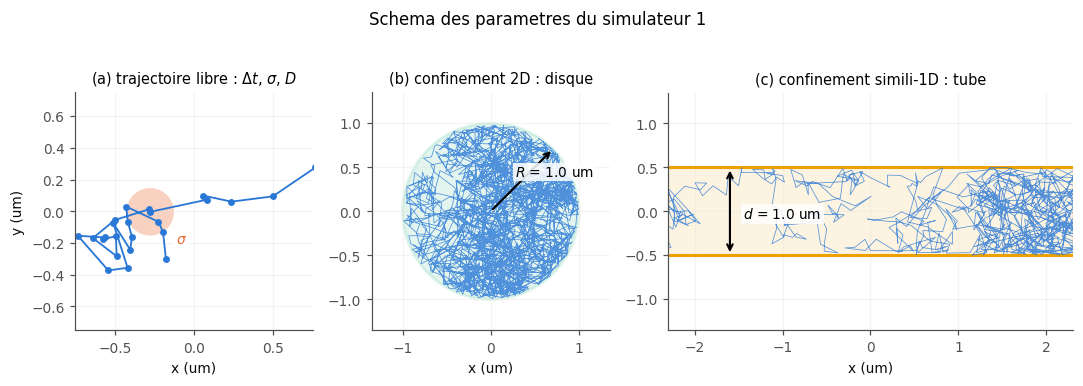

In [34]:
# --- parametres du simulateur 1 -------------------------------
D1 = 1          # coefficient de diffusion, um^2/s
DT1 = 0.01        # intervalle entre detections, s (100 images/s)
T1 = 10.0         # duree totale, s
SIG1 = 0.03       # precision de localisation, um
R_DISQUE = 1.0    # rayon du disque de confinement, um (cercle de 2 um de diametre)
D_TUBE = 1.0      # diametre du tube de confinement, um

fig, ax = plt.subplots(1, 3, figsize=(10, 3.2), width_ratios=[1, 1, 1.7])
BOITE = dict(fc="white", ec="none", alpha=.85, pad=1.5)


# (a) parametres d'une trajectoire
t, R = simuler(Plan(1.), D1, 0.3, DT1, n=1, seed=7)
xy = R[:, 0] - R[:, 0].mean(0)

ax[0].plot(*xy.T, "-o", color=CAT[0], ms=3.5, lw=1.2)
ax[0].add_patch(Circle(xy[12], SIG1*5, fc=CAT[1], alpha=.3, ec="none"))
ax[0].annotate("$\\Delta t$", xy[6], xy[6] + [.18, .18], color=CAT[3], fontweight="bold", bbox=BOITE, arrowprops=dict(arrowstyle="->", color=CAT[3], lw=1.4))
ax[0].annotate("$\\sigma$", xy[12] + [.16, -.20], color=CAT[1], fontweight="bold", bbox=BOITE)
ax[0].set_xlim(-.75, .75)
ax[0].set_ylim(-.75, .75)
ax[0].set_title("(a) trajectoire libre : $\\Delta t$, $\\sigma$, $D$")


# (b) confinement circulaire
t, Rd = simuler(Disque(R_DISQUE), D1, 20., DT1, n=1, seed=3)

ax[1].add_patch(Circle((0, 0), R_DISQUE, fc=CAT[2], alpha=.12, ec=CAT[2], lw=2))
ax[1].plot(*Rd[:, 0].T, color=CAT[0], lw=.5, alpha=.8)
ax[1].annotate("", (0, 0), (R_DISQUE*.71,)*2, arrowprops=dict(arrowstyle="<-", color="k", lw=1.4))
ax[1].annotate("$R$ = %.1f um" % R_DISQUE, (.28, .40), color="k", bbox=BOITE)
ax[1].set_xlim(-1.35, 1.35)
ax[1].set_ylim(-1.35, 1.35)
ax[1].set_title("(b) confinement 2D : disque")


# (c) confinement en tube
t, Rt = simuler(Tube(D_TUBE), D1, 20., DT1, n=1, seed=3)

ax[2].axhspan(-D_TUBE/2, D_TUBE/2, color=CAT[3], alpha=.12)

for y in (-D_TUBE/2, D_TUBE/2):
    ax[2].axhline(y, color=CAT[3], lw=2)

ax[2].plot(*(Rt[:, 0] - [Rt[:, 0, 0].mean(), 0]).T, color=CAT[0], lw=.5, alpha=.8)
ax[2].annotate("", (-1.6, -D_TUBE/2), (-1.6, D_TUBE/2), arrowprops=dict(arrowstyle="<->", color="k", lw=1.4))
ax[2].annotate("$d$ = %.1f um" % D_TUBE, (-1.45, -.08), color="k", bbox=BOITE)
ax[2].set_xlim(-2.3, 2.3)
ax[2].set_ylim(-1.35, 1.35)
ax[2].set_title("(c) confinement simili-1D : tube")


for a_ in ax:
    a_.set_aspect("equal")
    a_.set_xlabel("x (um)")
    a_.grid(alpha=.4)

ax[0].set_ylabel("y (um)")

fig.suptitle("Schema des parametres du simulateur 1", y=1.04)
plt.show()

## A) MSD d'une trajectoire et estimation de $D$

$\mathrm{MSD}(\tau) = 4D\tau$ en 2D : la pente aux courts décalages donne $D$.

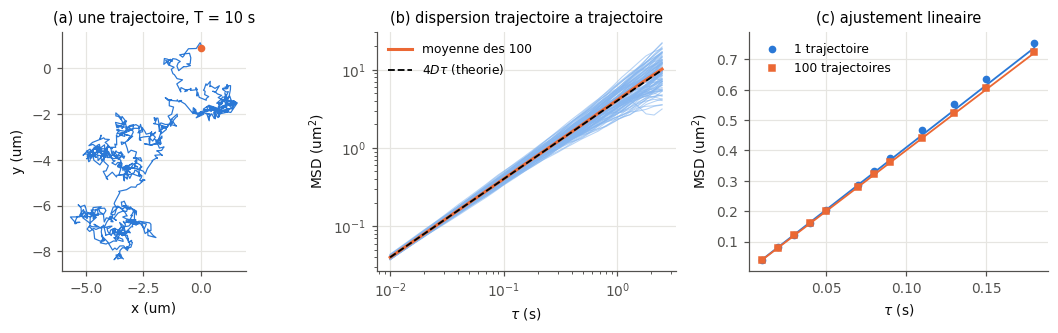

D vrai              : 1.000 um2/s
D, 1 trajectoire    : 1.025 um2/s
D, 100 trajectoires  : 1.002 um2/s


In [35]:
N = 100    # nombre de trajectoires à simuler

t, R = simuler(Plan(2.), D1, T1, DT1, n=N, seed=1)      # 20 trajectoires independantes
tau, m = msd(R[:, :1], DT1)                              # MSD d'une seule trajectoire
tau_e, m_e = msd(R, DT1)                                 # MSD moyennee sur les 20
D_1, _ = ajuste_msd(tau, m)
D_e, _ = ajuste_msd(tau_e, m_e)

fig, ax = plt.subplots(1, 3, figsize=(10, 3.1))
ax[0].plot(*R[:, 0].T, color=CAT[0], lw=.8)
ax[0].plot(*R[0, 0], "o", color=CAT[1], label="depart")
ax[0].set_aspect("equal")
ax[0].set_xlabel("x (um)")
ax[0].set_ylabel("y (um)")
ax[0].set_title("(a) une trajectoire, T = %g s" % T1)

for k in range(N):
    tk, mk = msd(R[:, k:k+1], DT1)
    ax[1].plot(tk, mk, color=SEQ[0], lw=.7, alpha=.6)

ax[1].plot(tau_e, m_e, color=CAT[1], label=f"moyenne des {N}")
ax[1].plot(tau_e, 4*D1*tau_e, "--", color="k", lw=1.2, label="$4D\\tau$ (theorie)")
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_xlabel("$\\tau$ (s)")
ax[1].set_ylabel("MSD (um$^2$)")
ax[1].legend()
ax[1].set_title("(b) dispersion trajectoire a trajectoire")

ax[2].plot(tau[:12], m[:12], "o", color=CAT[0], label="1 trajectoire")
ax[2].plot(tau[:12], 4*D_1*tau[:12], color=CAT[0], lw=1.2)
ax[2].plot(tau_e[:12], m_e[:12], "s", color=CAT[1], label=f"{N} trajectoires")
ax[2].plot(tau_e[:12], 4*D_e*tau_e[:12], color=CAT[1], lw=1.2)
ax[2].set_xlabel("$\\tau$ (s)")
ax[2].set_ylabel("MSD (um$^2$)")
ax[2].legend()
ax[2].set_title("(c) ajustement lineaire")

plt.show()

print("D vrai              : %.3f um2/s" % D1)
print("D, 1 trajectoire    : %.3f um2/s" % D_1)
print(f"D, {N} trajectoires  : %.3f um2/s" % D_e)


**Conclusion.** La pente de la MSD aux courts décalages restitue $D$ correctement. Une trajectoire
unique suffit pour un estimateur non biaisé, mais sa MSD diverge fortement aux grands $\tau$ :
le nombre de paires indépendantes y devient très petit. On n'ajuste donc que les premiers points.

## B) Impact de la durée de la simulation

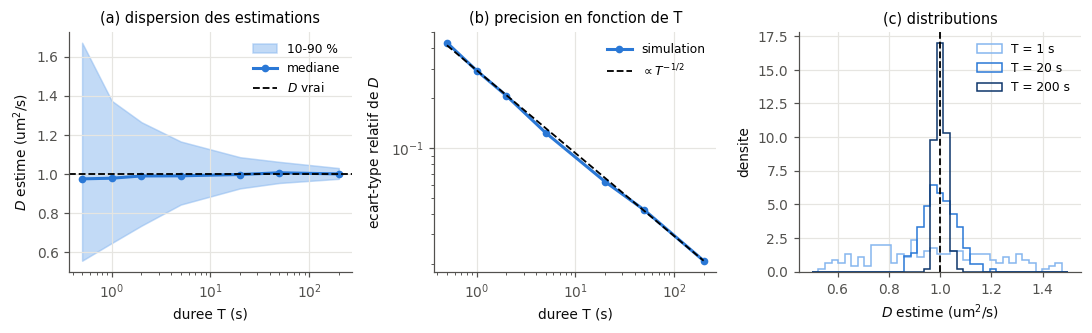

T =    0.5 s : D = 1.053 +- 0.455 um2/s  (43 %)
T =    1.0 s : D = 1.002 +- 0.294 um2/s  (29 %)
T =    2.0 s : D = 0.994 +- 0.206 um2/s  (21 %)
T =    5.0 s : D = 0.997 +- 0.123 um2/s  (12 %)
T =   20.0 s : D = 1.002 +- 0.063 um2/s  (6 %)
T =   50.0 s : D = 1.005 +- 0.042 um2/s  (4 %)
T =  200.0 s : D = 1.002 +- 0.021 um2/s  (2 %)


In [36]:
def D_par_trajectoire(R, dt, nlag=10):
    """
    D estime individuellement pour chaque trajectoire (nlag premiers decalages).
    """

    lags = np.arange(1, nlag + 1)
    m = np.array([((R[l:] - R[:-l])**2).sum(-1).mean(0) for l in lags])
    
    return np.polyfit(lags*dt, m, 1)[0]/4

t, R = simuler(Plan(2.), D1, 200., DT1, n=200, seed=11)   # 200 trajectoires de 200 s
durees = np.array([0.5, 1, 2, 5, 20, 50, 200])
est = [D_par_trajectoire(R[:int(T/DT1) + 1], DT1) for T in durees]
med = np.array([np.median(e) for e in est])
p10 = np.array([np.percentile(e, 10) for e in est])
p90 = np.array([np.percentile(e, 90) for e in est])
cv = np.array([e.std()/e.mean() for e in est])

fig, ax = plt.subplots(1, 3, figsize=(10, 3.1))

ax[0].fill_between(durees, p10, p90, color=SEQ[0], alpha=.5, label="10-90 %")
ax[0].plot(durees, med, "o-", color=CAT[0], label="mediane")
ax[0].axhline(D1, ls="--", color="k", lw=1.2, label="$D$ vrai")
ax[0].set_xscale("log")
ax[0].set_xlabel("duree T (s)")
ax[0].set_ylabel("$D$ estime (um$^2$/s)")
ax[0].legend()
ax[0].set_title("(a) dispersion des estimations")

ax[1].plot(durees, cv, "o-", color=CAT[0], label="simulation")
ax[1].plot(durees, cv[-1]*np.sqrt(durees[-1]/durees), "--", color="k", lw=1.2, label="$\\propto T^{-1/2}$")
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_xlabel("duree T (s)")
ax[1].set_ylabel("ecart-type relatif de $D$")
ax[1].legend()
ax[1].set_title("(b) precision en fonction de T")

for c, T in zip(seq(3), [1, 20, 200]):
    ax[2].hist(est[list(durees).index(T)], bins=np.linspace(0.5, 1.5, 40), histtype="step", color=c, lw=1.8, label="T = %g s" % T, density=True)

ax[2].axvline(D1, ls="--", color="k", lw=1.2)
ax[2].set_xlabel("$D$ estime (um$^2$/s)")
ax[2].set_ylabel("densite")
ax[2].legend()
ax[2].set_title("(c) distributions")

plt.show()

for T, e in zip(durees, est):
    print("T = %6.1f s : D = %.3f +- %.3f um2/s  (%.0f %%)" % (T, e.mean(), e.std(), 100*e.std()/e.mean()))


**Conclusion.** La durée ne change pas la valeur moyenne de $D$ : l'estimateur reste non biaisé.
Elle contrôle uniquement sa **précision**, qui s'améliore en $T^{-1/2}$. Sous 2 s (200 images),
la dispersion dépasse 25 % et une trajectoire isolée peut donner un $D$ deux fois trop grand ou
trop petit. C'est la raison pour laquelle on moyenne sur plusieurs trajectoires.

## C) Impact de la précision de localisation

Le bruit de localisation est décorrélé d'une image à l'autre : il ajoute une constante $4\sigma^2$
à la MSD 2D, sans modifier la pente (Michalet, éq. 14). On vérifie en même temps la règle du nombre
optimal de points $p_{\min} = E(2 + 2{,}7\sqrt{x})$ en comparant, sur des trajectoires **uniques**,
un ajustement à deux points à un ajustement à $p_{\min}$ points.

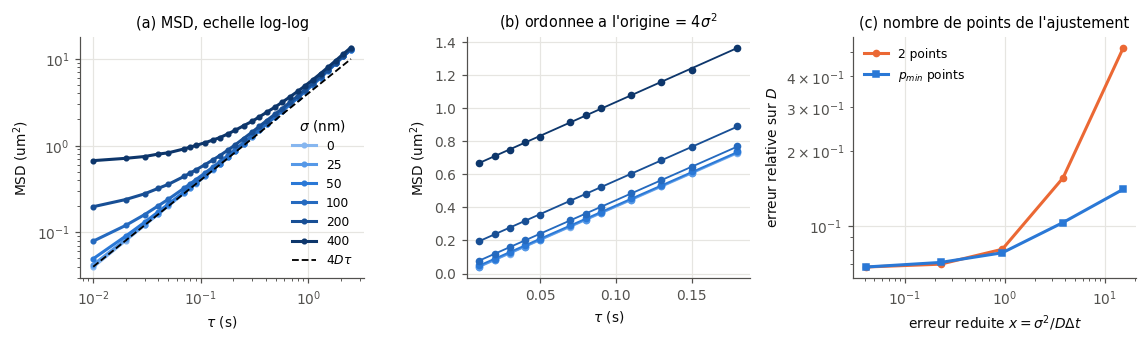

 sigma vrai   D estime    sigma estime      x     p_min   err(2 pts)  err(p_min)
      0 nm   1.008 um2/s       0 nm      0.000     2          7 %         7 %
     25 nm   1.011 um2/s      20 nm      0.041     2          7 %         7 %
     50 nm   1.007 um2/s      48 nm      0.229     3          7 %         7 %
    100 nm   1.012 um2/s      98 nm      0.947     4          8 %         8 %
    200 nm   1.017 um2/s     197 nm      3.833     7         16 %        10 %
    400 nm   1.021 um2/s     396 nm     15.380    12         52 %        14 %


In [37]:
sigmas = [0., 0.025, 0.05, 0.1, 0.2, 0.4]
t, R = simuler(Plan(2.), D1, 10.0, DT1, n=20, seed=21)

fig, ax = plt.subplots(1, 3, figsize=(10.5, 3.2))
res = []

for c, s in zip(seq(len(sigmas)), sigmas):
    if s:
        Rb_ = bruit_localisation(R, s)
    else:
        Rb_ = R

    tau, m = msd(Rb_, DT1)
    Df, sf = ajuste_msd(tau, m)
    x = sf**2/(Df*DT1)                                   # erreur de localisation reduite
    p = min(int(2 + 2.7*np.sqrt(x)), len(tau))           # Michalet eq. 30

    # dispersion des estimations sur des trajectoires uniques : 2 points contre p_min
    tau_p, mp = msd(Rb_, DT1, par_particule=True)
    D2 = np.array([ajuste_msd(tau_p, mp[:, k], npts=2)[0] for k in range(R.shape[1])])
    Dp = np.array([ajuste_msd(tau_p, mp[:, k], npts=p)[0] for k in range(R.shape[1])])
    res.append((s, Df, sf, x, p, D2.std()/abs(D2.mean()), Dp.std()/abs(Dp.mean())))

    ax[0].plot(tau, m, "o-", color=c, ms=3, label="%.0f" % (1000*s))
    ax[1].plot(tau[:12], m[:12], "o", color=c, ms=4)
    ax[1].plot(tau[:12], 4*Df*tau[:12] + 4*sf**2, color=c, lw=1.2)

ax[0].plot(tau, 4*D1*tau, "--", color="k", lw=1.2, label="$4D\\tau$")
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_xlabel("$\\tau$ (s)")
ax[0].set_ylabel("MSD (um$^2$)")
ax[0].legend(title="$\\sigma$ (nm)")
ax[0].set_title("(a) MSD, echelle log-log")
ax[1].set_xlabel("$\\tau$ (s)")
ax[1].set_ylabel("MSD (um$^2$)")
ax[1].set_title("(b) ordonnee a l'origine = $4\\sigma^2$")

xs = [r[3] for r in res[1:]]

ax[2].plot(xs, [r[5] for r in res[1:]], "o-", color=CAT[1], label="2 points")
ax[2].plot(xs, [r[6] for r in res[1:]], "s-", color=CAT[0], label="$p_{min}$ points")
ax[2].set_xscale("log")
ax[2].set_yscale("log")
ax[2].set_xlabel("erreur reduite $x = \\sigma^2/D\\Delta t$")
ax[2].set_ylabel("erreur relative sur $D$")
ax[2].legend()
ax[2].set_title("(c) nombre de points de l'ajustement")

plt.show()

print(" sigma vrai   D estime    sigma estime      x     p_min   err(2 pts)  err(p_min)")

for s, Df, sf, x, p, e2, ep in res:
    print("  %5.0f nm   %.3f um2/s   %5.0f nm   %8.3f   %3d    %7.0f %%   %7.0f %%" % (1000*s, Df, 1000*sf, x, p, 100*e2, 100*ep))


**Conclusion.** La précision de localisation décale la MSD vers le haut d'une constante $4\sigma^2$
sans changer la pente. Conséquences :

- $D$ reste correctement estimé **si** on ajuste une droite avec ordonnée à l'origine libre ;
  forcer le passage par zéro surestime $D$. Michalet insiste sur le point inverse : avec le temps de
  pose, l'ordonnée peut être **négative** ($a = 4\sigma^2 - \frac43 D t_E$) et la contraindre à
  rester positive biaise $D$ vers le bas.
- L'ordonnée à l'origine mesure $\sigma$ et le résultat est fidèle, à quelques nanomètres près.
- Le régime de courts $\tau$ devient plat : dès que $4\sigma^2 > 4D\Delta t$, c'est-à-dire dès que
  l'erreur réduite $x = \sigma^2/D\Delta t$ dépasse 1 ($\sigma > \sqrt{D\Delta t} \approx 70$ nm
  ici), le mouvement réel est noyé dans le bruit sur les premiers points.
- **Le nombre de points ajustés compte autant que le modèle.** Tant que $x \lesssim 1$, deux ou
  trois points suffisent et les deux stratégies se valent. Dès que $x$ dépasse quelques unités,
  l'ajustement à deux points se disperse rapidement (44 % d'erreur relative à $x = 31$) alors que
  $p_{\min} = E(2+2{,}7\sqrt{x})$ la maintient à 8 %. C'est le résultat central de Michalet : un
  nombre de points mal choisi peut fausser $D$ de plusieurs ordres de grandeur.

## D) Confinement

Cercle de 2 µm de diamètre ($R$ = 1 µm) et tube de 1 µm de diamètre.
Une particule confinée sature : $\mathrm{MSD}(\infty) = 2(\mathrm{Var}\,x + \mathrm{Var}\,y)$.

- disque uniforme : $\mathrm{Var}\,x = \mathrm{Var}\,y = R^2/4 \Rightarrow$ plateau $= R^2$
- segment de largeur $d$ : $\mathrm{Var} = d^2/12 \Rightarrow$ plateau 1D $= d^2/6$

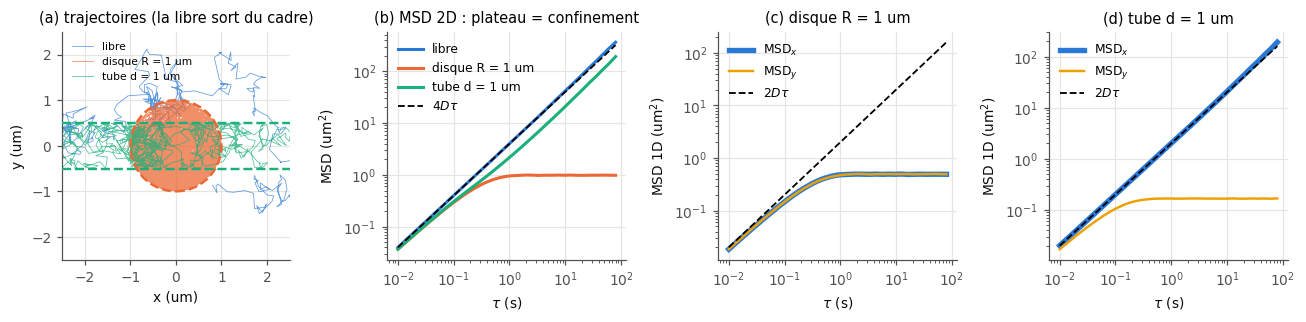

disque : plateau 2D = 0.986 um2  ->  R = 0.99 um (vrai 1.00)
tube   : plateau y  = 0.167 um2  ->  d = 1.00 um (vrai 1.00)
tube   : MSD_x lineaire, D_x = 1.000 um2/s (vrai 1.00)


In [38]:
T_LONG = 200.

geoms = [("libre", Plan(2.), CAT[0]),
         ("disque R = 1 um", Disque(R_DISQUE), CAT[1]),
         ("tube d = 1 um", Tube(D_TUBE), CAT[2])]

fig, ax = plt.subplots(1, 4, figsize=(12, 3.0))
traj = {}

for k, (nom, dom, c) in enumerate(geoms):
    t, R = simuler(dom, D1, T_LONG, DT1, n=30, seed=31)
    traj[nom] = R
    ax[0].plot(*R[:5000, 0].T, color=c, lw=.5, alpha=.75, label=nom)   # 50 s, cadre +-2.5 um
    tau, m = msd(R, DT1, frac=0.4)
    ax[1].plot(tau, m, color=c, lw=2, label=nom)

ax[0].add_patch(Circle((0, 0), R_DISQUE, fill=False, ec=CAT[1], lw=1.6, ls="--", zorder=5))

for y in (-D_TUBE/2, D_TUBE/2):
    ax[0].axhline(y, color=CAT[2], lw=1.6, ls="--", zorder=5)

ax[0].set_xlim(-2.5, 2.5)
ax[0].set_ylim(-2.5, 2.5)
ax[0].set_aspect("equal")
ax[0].set_xlabel("x (um)")
ax[0].set_ylabel("y (um)")
ax[0].legend(loc="upper left", fontsize=7)
ax[0].set_title("(a) trajectoires (la libre sort du cadre)")

ax[1].plot(tau, 4*D1*tau, "--", color="k", lw=1.2, label="$4D\\tau$")
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_xlabel("$\\tau$ (s)")
ax[1].set_ylabel("MSD (um$^2$)")
ax[1].legend()
ax[1].set_title("(b) MSD 2D : plateau = confinement")

# decouplage des deux axes
for k, (nom, ax_k) in enumerate([("disque R = 1 um", ax[2]), ("tube d = 1 um", ax[3])]):
    for axe, lab, c, w in [(0, "x", CAT[0], 3.5), (1, "y", CAT[3], 1.6)]:
        tau, m = msd(traj[nom], DT1, frac=0.4, axe=axe)
        ax_k.plot(tau, m, color=c, lw=w, label="MSD$_%s$" % lab)

    ax_k.plot(tau, 2*D1*tau, "--", color="k", lw=1.2, label="$2D\\tau$")
    ax_k.set_xscale("log")
    ax_k.set_yscale("log")
    ax_k.set_xlabel("$\\tau$ (s)")
    ax_k.set_ylabel("MSD 1D (um$^2$)")
    ax_k.legend()
    ax_k.set_title("(%s) %s" % ("cd"[k], nom))

plt.show()

tau, m = msd(traj["disque R = 1 um"], DT1, frac=0.4)
print("disque : plateau 2D = %.3f um2  ->  R = %.2f um (vrai %.2f)" % (plateau(tau, m), np.sqrt(plateau(tau, m)), R_DISQUE))

tau, my = msd(traj["tube d = 1 um"], DT1, frac=0.4, axe=1)
print("tube   : plateau y  = %.3f um2  ->  d = %.2f um (vrai %.2f)" % (plateau(tau, my), np.sqrt(6*plateau(tau, my)), D_TUBE))

tau, mx = msd(traj["tube d = 1 um"], DT1, frac=0.4, axe=0)
print("tube   : MSD_x lineaire, D_x = %.3f um2/s (vrai %.2f)" % (ajuste_msd(tau, mx, ndim=1)[0], D1))

**Conclusion.**

- Le confinement fait **saturer** la MSD : elle suit $4D\tau$ aux courts $\tau$, puis s'infléchit
  et atteint un plateau au temps caractéristique $\tau_c \approx R^2/D$.
- Le plateau donne directement la taille du domaine : $R = \sqrt{\mathrm{MSD}_\infty}$ pour le
  disque, $d = \sqrt{6\,\mathrm{MSD}_{y,\infty}}$ pour le tube. Les deux tailles sont retrouvées
  à quelques pour cent.
- **Le découplage des axes est indispensable pour le tube.** En 2D, la MSD totale du tube reste
  croissante (le mouvement libre selon $x$ masque le confinement) et on pourrait conclure à tort à
  une diffusion libre plus lente. Projetée sur chaque axe, la signature est sans ambiguïté :
  MSD$_x$ reste linéaire de pente $2D$, MSD$_y$ plafonne. Pour le disque, les deux axes plafonnent
  à la même valeur $R^2/2$, ce qui signe un confinement isotrope.

## E) Film vu par une caméra

La trajectoire est convoluée par une PSF gaussienne, échantillonnée par les pixels, puis un fond et
un bruit de Poisson sont ajoutés.

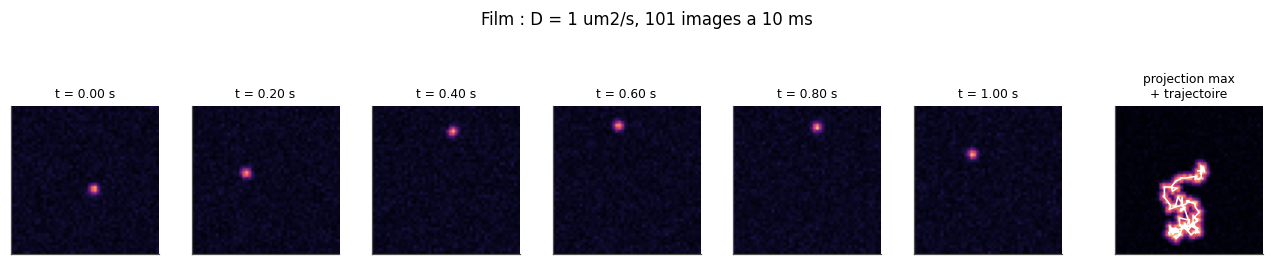

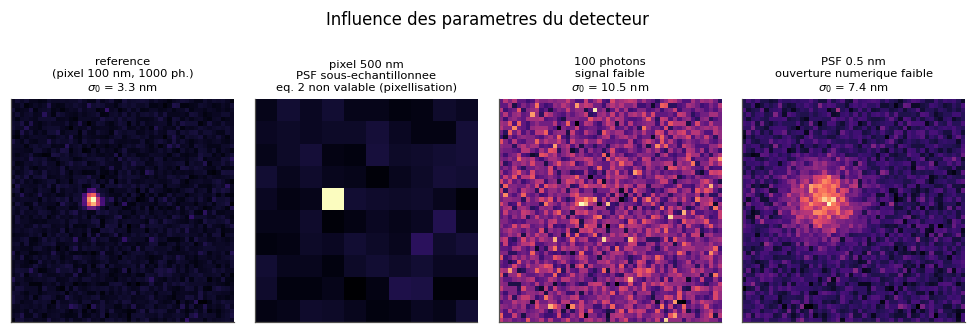

PSF                 : sigma = 105 nm  (FWHM = 247 nm), lambda = 0.5 um, NA = 1.0
Pixel               : 100 nm  -> 1.0 pixels par sigma de PSF (critere de Nyquist)
Photons / molecule  : 1000 par image ; fond : 10 photons/pixel
Localisation        : sigma_0 = s0/sqrt(N) = 3.3 nm  (statique, Michalet eq. 2)
                      sigma   = 4.6 nm  (pose t_E = 10 ms, eq. 4)
Deplacement / image : sqrt(4 D dt) = 200 nm
Erreur reduite      : x = sigma^2/(D dt) = 1.1e-03  ->  p_min = 2 points de MSD


In [39]:
# --- parametres du detecteur ------------------------------------------------
LAMBDA = 0.500          # longueur d'onde d'emission, um
NA = 1.0                # ouverture numerique
PSF = 0.21*LAMBDA/NA    # ecart-type de la PSF ~ 0.21 lambda/NA
CHAMP = 5               # largeur du champ, um
PIXEL = 0.1             # largeur d'un pixel, um
PHOTONS = 1000          # nombre de photons détectés

cam = Camera(pixel=PIXEL, psf=PSF, champ=CHAMP, photons=PHOTONS, fond=10)

t, R = simuler(Plan(1.), D1, 1.0, DT1, n=1, seed=5)
film = cam.film(R, seed=2)

fig, ax = plt.subplots(1, 7, figsize=(12, 2.1), width_ratios=[1]*6 + [1.25])

for a_, i in zip(ax, np.linspace(0, len(film) - 1, 6).astype(int)):
    a_.imshow(film[i], vmin=0, vmax=film.max())
    a_.set_title("t = %.2f s" % t[i], fontsize=8)

ax[6].imshow(film.max(0), extent=[-cam.champ/2, cam.champ/2]*2, origin="lower")
ax[6].plot(*R[:, 0].T, color="w", lw=1)
ax[6].set_title("projection max\n+ trajectoire", fontsize=8)

for a_ in ax:
    a_.set_xticks([])
    a_.set_yticks([])
    a_.grid(False)

fig.suptitle("Film : D = %g um2/s, %d images a %g ms" % (D1, len(film), 1e3*DT1), y=1.12)

plt.show()

# influence de chaque parametre du detecteur, sur la meme position
variantes = [(f"reference\n(pixel {PIXEL*1000:.0f} nm, {PHOTONS} ph.)", cam, True),
             (f"pixel {PIXEL*5*1000:.0f} nm\nPSF sous-echantillonnee",
              Camera(pixel=PIXEL*5, psf=PSF, champ=CHAMP, photons=PHOTONS//10, fond=10), False),
             (f"{PHOTONS//10} photons\nsignal faible",
              Camera(pixel=PIXEL, psf=PSF, champ=CHAMP, photons=PHOTONS//10, fond=10), True),
             (f"PSF {PSF*5:.1f} nm\nouverture numerique faible",
              Camera(pixel=PIXEL, psf=PSF*5, champ=CHAMP, photons=PHOTONS*5, fond=10), True)]

fig, ax = plt.subplots(1, 4, figsize=(9, 2.7))

for a_, (titre, c, valide) in zip(ax, variantes):
    a_.imshow(c.image(R[20], np.random.default_rng(1)))

    if valide:
        sous_titre = "$\\sigma_0$ = %.1f nm" % (1000*c.precision)
    else:
        sous_titre = "eq. 2 non valable (pixellisation)"

    a_.set_title("%s\n%s" % (titre, sous_titre), fontsize=7.5)
    a_.set_xticks([])
    a_.set_yticks([])
    a_.grid(False)

fig.suptitle("Influence des parametres du detecteur", y=1.10)

plt.show()

print("PSF                 : sigma = %.0f nm  (FWHM = %.0f nm), lambda = %g um, NA = %.1f" % (1000*PSF, 1000*2.355*PSF, LAMBDA, NA))
print("Pixel               : %.0f nm  -> %.1f pixels par sigma de PSF (critere de Nyquist)" % (1000*cam.pixel, PSF/cam.pixel))
print("Photons / molecule  : %d par image ; fond : %d photons/pixel" % (cam.photons, cam.fond))
print("Localisation        : sigma_0 = s0/sqrt(N) = %.1f nm  (statique, Michalet eq. 2)" % (1000*cam.precision))
print("                      sigma   = %.1f nm  (pose t_E = %g ms, eq. 4)" % (1000*cam.precision_dynamique(D1, DT1), 1e3*DT1))
print("Deplacement / image : sqrt(4 D dt) = %.0f nm" % (1000*np.sqrt(4*D1*DT1)))
print("Erreur reduite      : x = sigma^2/(D dt) = %.1e  ->  p_min = %d points de MSD" % (cam.precision**2/(D1*DT1), int(2 + 2.7*np.sqrt(cam.precision**2/(D1*DT1)))))

**Conclusion — choix des paramètres.**

- **PSF** : $s_0 \simeq 0{,}21\,\lambda/\mathrm{NA} = 78$ nm (FWHM 184 nm) pour
  $\lambda$ = 520 nm et NA = 1,4. C'est la limite de diffraction ; élargir la PSF dégrade
  directement la précision de localisation.
- **Pixel** : 100 nm, soit 0,8 pixel par $s_0$ (il faut au moins deux pixels par FWHM, soit
  92 nm). Trop gros (300 nm), la PSF n'est plus échantillonnée : l'information de position est
  perdue et $\sigma_0 = s_0/\sqrt N$, qui néglige justement la pixellisation, cesse de s'appliquer.
  Trop petit, les photons sont répartis sur trop de pixels et le bruit de lecture domine.
- **Photons** : 600 par molécule et par image, soit $\sigma_0 = s_0/\sqrt N$ = 3,2 nm, très
  inférieur au déplacement par image ($\sqrt{4D\Delta t}$ = 141 nm) : la trajectoire est largement
  sur-résolue. À 60 photons la précision tombe à 10 nm, et une PSF dégradée à 350 nm la porte à
  14 nm. La correction de pose (éq. 4) ajoute encore 35 % ici, car $D t_E \simeq s_0^2$.
- **Lien avec la partie C** : avec ces photons, $x = \sigma^2/(D\Delta t) \approx 2\times10^{-3}$,
  donc $p_{\min} = 2$ : deux points de MSD suffisent. C'est le régime $x \ll 1$ de Michalet.
- **Fond et bruit de Poisson** : le fond (10 photons/pixel) ajoute du bruit sans signal et pénalise
  surtout les images faibles ; le bruit de grenaille est la limite fondamentale.
- **$\Delta t$** : 10 ms fixe à la fois la fréquence d'images et le déplacement par image. Il doit
  rester petit devant le temps de confinement mais assez grand pour collecter des photons.

<a id="2"></a>
# 2. Simulateur 2 — FRAP

Population de particules indépendantes dans une boîte à parois réfléchissantes. Paramètres :
durée $T$, pas $\Delta t$, densité de particules, coefficient de diffusion $D$, fraction immobile,
rayon de la zone blanchie $R_b$.

Référence : **Kenworthy, *Biophys. J.* 122, 3577 (2023)**. L'article rappelle qu'une courbe de FRAP
porte deux informations distinctes, la **cinétique** (caractérisée par $t_{1/2}$) et la **fraction
mobile**, et que le choix du modèle doit tenir compte de la géométrie et de la taille de la zone
blanchie, des conditions aux limites et du nombre de dimensions du retour. C'est le plan des trois
parties ci-dessous. Les trois hypothèses de base qu'il liste (blanchiment irréversible, variations
de fluorescence dues aux seules molécules marquées, marquage non perturbant) sont ici satisfaites
par construction.

## Film FRAP vu par la caméra

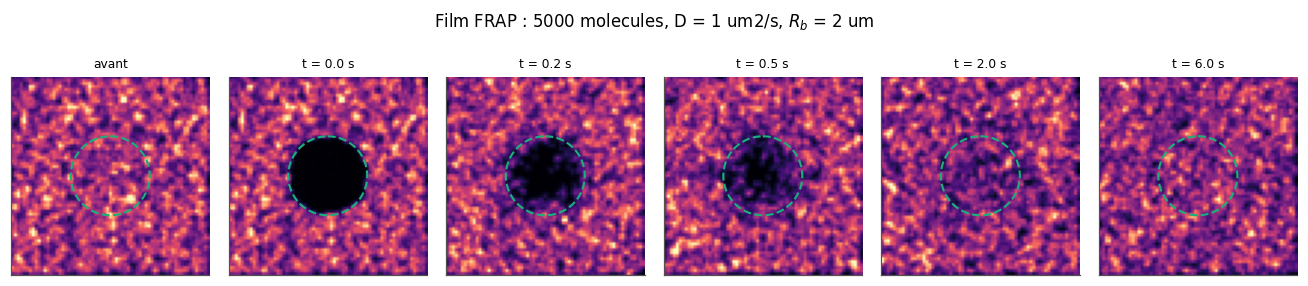

In [40]:
# --- parametres de reference du simulateur 2 -------------------------------
L2 = 10.0                   # cote de la boite, um (grande devant Rb pour un reservoir quasi infini)
RB = 2.0                    # rayon de la zone blanchie, um
DENS2 = 50.0                # densite, molecules / um^2
N2 = int(DENS2*L2**2)       # nombre de molecules
D2 = 1.0                    # coefficient de diffusion, um^2/s

t, R = simuler(Boite(L2), D2, 6.0, 0.05, n=N2, seed=41)
fluo = (R[0]**2).sum(-1) >= RB**2                 # molecules non blanchies
cam = Camera(pixel=0.15, psf=PSF, champ=10., photons=200, fond=5)

instants = [0, 0, 4, 10, 40, 120]
fig, ax = plt.subplots(1, 6, figsize=(12, 2.4))
rng = np.random.default_rng(3)
ech = cam.image(R[0], rng)                          # image avant blanchiment
vmax = np.percentile(ech, 99.5)

for k, (a, i) in enumerate(zip(ax, instants)):
    if k == 0:
        m = np.ones(N2, bool)          # 1re vignette : avant blanchiment
        titre = "avant"
    else:
        m = fluo
        titre = "t = %.1f s" % t[i]

    a.imshow(cam.image(R[i][m], rng), vmin=0, vmax=vmax)
    a.add_patch(Circle((cam.npix/2 - .5,)*2, RB/cam.pixel, fill=False, ec=CAT[2], lw=1.4, ls="--"))
    a.set_title(titre, fontsize=8)
    a.set_xticks([])
    a.set_yticks([])
    a.grid(False)

fig.suptitle("Film FRAP : %d molecules, D = %g um2/s, $R_b$ = %g um" % (N2, D2, RB), y=1.06)

plt.show()


## A) Impact du coefficient de diffusion

$\Delta t$ et $T$ sont mis à l'échelle du temps caractéristique $R_b^2/D$, ce qui garde le même
nombre de points utiles quel que soit $D$. La boîte est grande devant $R_b$ (rapport d'aire
inférieur à 2 %) pour que le réservoir de molécules fluorescentes hors du disque soit quasi
inépuisable et que le plateau tende vers 1.

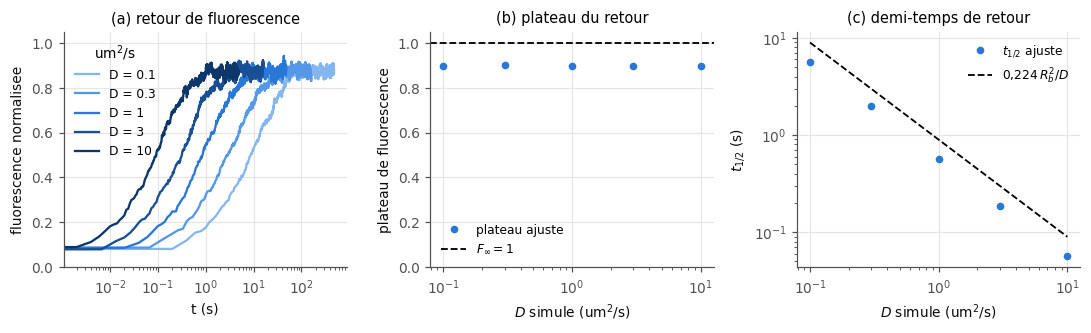

  D simule    t_1/2 (s)    D mesure    fraction mobile
     0.10       5.591        0.16    0.90
     0.30       1.975        0.45    0.90
     1.00       0.561        1.59    0.90
     3.00       0.187        4.80    0.90
    10.00       0.056       15.87    0.90


In [41]:
Ds = [0.1, 0.3, 1.0, 3.0, 10.0]
courbes = []
ajust = []

for k, D in enumerate(Ds):
    t, F = frap(Boite(L2), D, RB, 12*RB**2/D, 0.005*RB**2/D, N2, n_rep=4, seed=50 + 10*k)
    courbes.append((t, F))
    ajust.append(ajuste_frap(t, F, RB))

fig, ax = plt.subplots(1, 3, figsize=(10, 3.1))

for c, D, (t, F) in zip(seq(len(Ds)), Ds, courbes):
    ax[0].plot(t, F, color=c, lw=1.5, label="D = %g" % D)

ax[0].set_xscale("log")
ax[0].set_xlabel("t (s)")
ax[0].set_ylabel("fluorescence normalisee")
ax[0].set_ylim(0, 1.05)
ax[0].legend(title="um$^2$/s")
ax[0].set_title("(a) retour de fluorescence")

plateaux = [a["mobile"] for a in ajust]

ax[1].plot(Ds, plateaux, "o", color=CAT[0], label="plateau ajuste")
ax[1].axhline(1.0, ls="--", color="k", lw=1.2, label="$F_\\infty = 1$")
ax[1].set_xscale("log")
ax[1].set_ylim(0, 1.05)
ax[1].set_xlabel("$D$ simule (um$^2$/s)")
ax[1].set_ylabel("plateau de fluorescence")
ax[1].legend()
ax[1].set_title("(b) plateau du retour")

t_demis = [a["t_demi"] for a in ajust]

ax[2].plot(Ds, t_demis, "o", color=CAT[0], label="$t_{1/2}$ ajuste")
ax[2].plot(Ds, 0.2236*RB**2/np.array(Ds), "--", color="k", lw=1.2, label="$0{,}224\\,R_b^2/D$")
ax[2].set_xscale("log")
ax[2].set_yscale("log")
ax[2].set_xlabel("$D$ simule (um$^2$/s)")
ax[2].set_ylabel("$t_{1/2}$ (s)")
ax[2].legend()
ax[2].set_title("(c) demi-temps de retour")

plt.show()

print("  D simule    t_1/2 (s)    D mesure    fraction mobile")

for D, a in zip(Ds, ajust):
    print("  %7.2f    %8.3f    %8.2f    %.2f" % (D, a["t_demi"], a["D"], a["mobile"]))

**Conclusion.** Le retour est d'autant plus rapide que $D$ est grand, avec
$t_{1/2} = 0{,}224\,R_b^2/D$ (panneau c) : un facteur 100 sur $D$ donne un facteur 100 sur
$t_{1/2}$. Le plateau, lui, ne dépend pas de $D$ et reste proche de 1 dans tous les cas
(panneau b), puisque la boîte est grande devant $R_b$ : le réservoir de molécules fluorescentes
n'est jamais appauvri de façon mesurable.

Un point de méthode : il faut ajuster le plateau **en même temps** que $D$. Le lire directement sur
la fin de la courbe le sous-estime de quelques pour cent, parce que le retour se termine par une
queue lente, et cette petite erreur se répercute en une surestimation de $D$ de 20 % ou plus.

## B) Impact de la population immobile

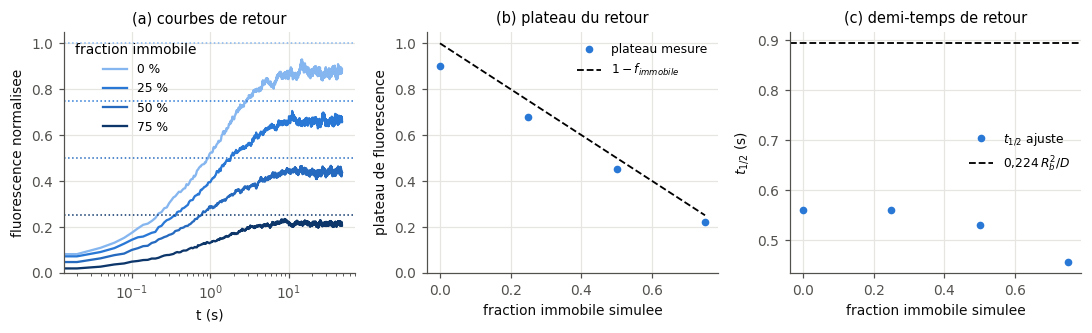

  f_immobile   plateau mesure   t_1/2 (s)   D mesure (um2/s)
      0.00           0.90         0.561        1.60
      0.25           0.68         0.561        1.60
      0.50           0.45         0.530        1.69
      0.75           0.22         0.457        1.96


In [42]:
f_imm = [0., 0.25, 0.5, 0.75]
res_b = []

for k, fi in enumerate(f_imm):
    t, F = frap(Boite(L2), D2, RB, 12*RB**2/D2, 0.005*RB**2/D2, N2, f_immobile=fi, n_rep=6, seed=80 + 10*k)
    res_b.append((t, F, ajuste_frap(t, F, RB)))

fig, ax = plt.subplots(1, 3, figsize=(10, 3.1))

for c, fi, (t, F, a) in zip(seq(len(f_imm)), f_imm, res_b):
    ax[0].plot(t, F, color=c, lw=1.5, label="%.0f %%" % (100*fi))
    ax[0].axhline(1 - fi, color=c, ls=":", lw=1)

ax[0].set_xscale("log")
ax[0].set_xlabel("t (s)")
ax[0].set_ylabel("fluorescence normalisee")
ax[0].set_ylim(0, 1.05)
ax[0].legend(title="fraction immobile")
ax[0].set_title("(a) courbes de retour")

ax[1].plot(f_imm, [a["mobile"] for _, _, a in res_b], "o", color=CAT[0], label="plateau mesure")
ax[1].plot(f_imm, 1 - np.array(f_imm), "--", color="k", lw=1.2, label="$1 - f_{immobile}$")
ax[1].set_ylim(0, 1.05)
ax[1].set_xlabel("fraction immobile simulee")
ax[1].set_ylabel("plateau de fluorescence")
ax[1].legend()
ax[1].set_title("(b) plateau du retour")

ax[2].plot(f_imm, [a["t_demi"] for _, _, a in res_b], "o", color=CAT[0], label="$t_{1/2}$ ajuste")
ax[2].axhline(0.2236*RB**2/D2, ls="--", color="k", lw=1.2, label="$0{,}224\\,R_b^2/D$")
ax[2].set_xlabel("fraction immobile simulee")
ax[2].set_ylabel("$t_{1/2}$ (s)")
ax[2].legend(loc="center right")
ax[2].set_title("(c) demi-temps de retour")

plt.show()

print("  f_immobile   plateau mesure   t_1/2 (s)   D mesure (um2/s)")

for fi, (_, _, a) in zip(f_imm, res_b):
    print("  %8.2f     %10.2f      %8.3f    %8.2f" % (fi, a["mobile"], a["t_demi"], a["D"]))

**Conclusion.** La population immobile ne change pas la **vitesse** du retour, seulement son
**amplitude finale** (panneau b) : le plateau vaut exactement $1 - f_{\rm immobile}$. Les molécules
fixes blanchies restent dans la zone et n'en sortent jamais, celles de l'extérieur n'y entrent
jamais. La fluorescence manquante au plateau est donc la mesure directe de la fraction immobile,
tandis que $t_{1/2}$ (panneau c) reste stable autour de sa valeur théorique et continue de mesurer
$D$ de la population mobile, indépendamment de la fraction immobile : les deux informations
n'interfèrent pas. Le $D$ ajusté fluctue tout de même de quelques dizaines de pour cent d'un cas à
l'autre, car il est d'autant plus difficile à extraire que l'amplitude qui remonte est faible.

## C) Impact de la géométrie : 2D libre contre tube de 1 µm

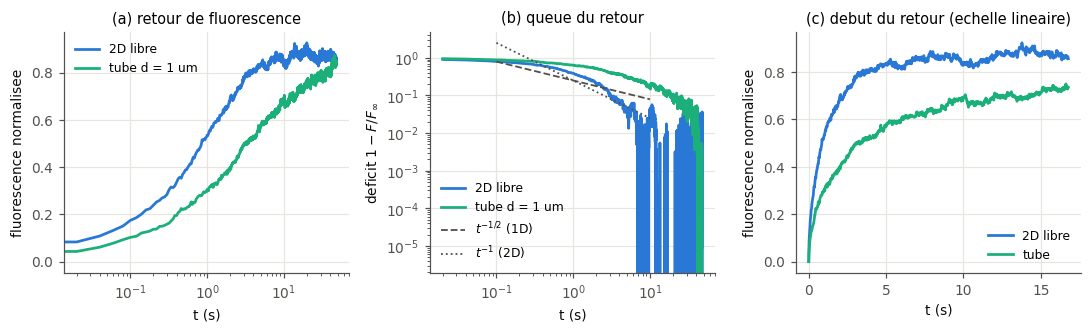

2D libre       : plateau 0.89  |  D par le modele 2D = 1.73 um2/s  (vrai 1.0)
tube d = 1 um  : plateau 0.86  |  D par le modele 2D = 0.36 um2/s  (vrai 1.0)


In [43]:
L_TUBE = 100.0
DENS_TUBE = 100.0

geo = [("2D libre", Boite(L2), N2, CAT[0]),
       ("tube d = 1 um", Tube(1.0, L_TUBE), int(DENS_TUBE*L_TUBE), CAT[2])]
res_c = []

for nom, dom, n, c in geo:
    t, F = frap(dom, D2, RB, 12*RB**2, 0.005*RB**2, n, n_rep=4, seed=200)
    res_c.append((nom, t, F, c))

fig, ax = plt.subplots(1, 3, figsize=(10, 3.1))
for nom, t, F, c in res_c:
    A = F[int(0.8*len(F)):].mean()
    ax[0].plot(t, F, color=c, lw=1.8, label=nom)
    ax[1].plot(t[1:], 1 - F[1:]/A, color=c, lw=1.8, label=nom)

ax[0].set_xscale("log")
ax[0].set_xlabel("t (s)")
ax[0].set_ylabel("fluorescence normalisee")
ax[0].legend()
ax[0].set_title("(a) retour de fluorescence")

tt = np.logspace(-1, 1, 20)

ax[1].plot(tt, 0.25*tt**-0.5, "--", color=GRIS, lw=1.2, label="$t^{-1/2}$ (1D)")
ax[1].plot(tt, 0.25*tt**-1., ":", color=GRIS, lw=1.2, label="$t^{-1}$ (2D)")
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_xlabel("t (s)")
ax[1].set_ylabel("deficit $1 - F/F_\\infty$")
ax[1].legend()
ax[1].set_title("(b) queue du retour")

t, F = res_c[0][1], res_c[0][2]
i = int(0.35*len(t))

ax[2].plot(t[:i], res_c[0][2][:i], color=CAT[0], lw=1.8, label="2D libre")
ax[2].plot(t[:i], res_c[1][2][:i], color=CAT[2], lw=1.8, label="tube")
ax[2].set_xlabel("t (s)")
ax[2].set_ylabel("fluorescence normalisee")
ax[2].legend()
ax[2].set_title("(c) debut du retour (echelle lineaire)")

plt.show()

for nom, t, F, c in res_c:
    a = ajuste_frap(t, F, RB)
    print("%-14s : plateau %.2f  |  D par le modele 2D = %.2f um2/s  (vrai %.1f)" % (nom, a["mobile"], a["D"], D2))

**Conclusion.** La géométrie change la **forme** de la courbe, pas seulement son échelle de temps.

- En 2D, le remplissage se fait par tout le périmètre du disque : le retour est rapide et le déficit
  décroît en $1/t$.
- Dans le tube, les molécules n'arrivent que par les deux extrémités. Le retour est nettement plus
  lent et sa queue suit $t^{-1/2}$, signature du transport unidimensionnel.
- Conséquence pratique : appliquer le modèle 2D du disque uniforme à des données de tube
  **sous-estime** $D$ d'un facteur 3 et laisse un résidu systématique. La lenteur du retour est ici
  un effet de géométrie, pas de mobilité. C'est exactement le point soulevé par Kenworthy : le
  modèle doit tenir compte des conditions aux limites et du fait que le retour se fasse en une, deux
  ou trois dimensions. Il faut donc vérifier la forme de la courbe, et pas seulement lire
  $t_{1/2}$, avant de conclure à une diffusion ralentie.

<a id="3"></a>
# 3. Simulateur 3 — FCS

Un laser gaussien est focalisé au centre de la boîte. On enregistre la trace de fluorescence
$F(t)$ et on calcule $G(\tau) = \langle \delta F(t)\,\delta F(t+\tau)\rangle / \langle F\rangle^2$.

L'ajustement donne $N = 1/G(0)$ (nombre d'émetteurs dans la surface effective $\pi w_0^2$) et
$\tau_D = w_0^2/4D$ (temps de résidence).

Les paramètres reproduisent une mesure de FCS confocale sur une membrane : faisceau de rayon
$w_0$ = 0,25 µm à $1/e^2$ (objectif à immersion NA 1,2, émission ~520 nm), brillance de 20 kHz par
molécule, densités de 0,5 à 51 molécules/µm² et coefficients de diffusion de 0,1 à 10 µm²/s, qui
couvrent la gamme des lipides et des protéines membranaires. Le binning et la durée d'acquisition
sont calés sur le temps de résidence attendu, à raison de 100 points par $\tau_D$ et de
1000 $\tau_D$ par acquisition : c'est ce qui donne des courbes de même qualité sur toute la gamme.

Référence : **Yu *et al.*, *Front. Phys.* 9, 644450 (2021)**, dont on reprend la définition de
$G(\tau)$ (éq. 1), le modèle de diffusion réduit au cas 2D (éq. 2) et les ordres de grandeur du
tableau 1 pour la FCS conventionnelle : gamme de concentration de 1 pM à 100 nM, $D$ mesurable
jusqu'à 300 µm²/s, durée d'acquisition typique de 10 à 120 s.

## Mesure de référence : densité et temps de résidence

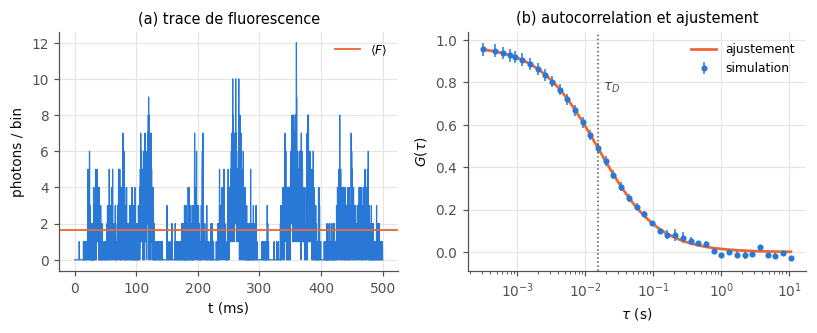

Faisceau     : w0 = 0.25 um -> surface effective pi*w0^2 = 0.196 um2
Boite        : 4 x 4 um (18 w0), 103 molecules -> 5.1 molecules/um2
Acquisition  : dt = 156 us, T = 15.6 s = 1000 tau_D, 100000 points
Photons      : 20 kHz par molecule -> 1.6 photons/bin en moyenne

N     : 1.03 emetteurs   (simule : 1.00)
tau_D : 15.6 ms          (attendu : 15.6 ms)
D     : 1.00 um2/s       (simule : 1.00)


In [44]:
# --- parametres de reference du simulateur 3 -------------------------------
W0 = 0.25         # rayon du faisceau a 1/e^2, um (valeur calibree typique)
L3 = 4.5          # cote de la boite, um = 18 w0 : en dessous, les parois biaisent tau_D
D3 = 1.0          # coefficient de diffusion, um^2/s
N_EFF = 1.0       # emetteurs par surface effective pi*w0^2
CPS = 2e4         # brillance : 20 kHz par molecule au centre du faisceau

TAU_D3 = W0**2/(4*D3)
DT3 = TAU_D3/100
T3 = 1000*TAU_D3
n3 = n_particules(N_EFF, L3**2, W0)

tau, G, err = fcs(Boite(L3), D3, T3, DT3, n3, Faisceau(W0), n_rep=8, seed=1, cps=CPS)
res = ajuste_fcs(tau, G, W0)

fig, ax = plt.subplots(1, 2, figsize=(7.5, 3.1))

t, F = traces(Boite(L3), D3, T3, DT3, n3, Faisceau(W0), cps=CPS, seed=1)
fen = t <= 0.5

ax[0].plot(t[fen]*1e3, F[fen], color=CAT[0], lw=.8)
ax[0].axhline(F.mean(), color=CAT[1], lw=1.2, label="$\\langle F \\rangle$")
ax[0].set_xlabel("t (ms)")
ax[0].set_ylabel("photons / bin")
ax[0].legend()
ax[0].set_title("(a) trace de fluorescence")

ax[1].errorbar(tau, G, err, fmt="o", color=CAT[0], ms=3, lw=1, label="simulation")
ax[1].plot(tau, modele_fcs(tau, 1/res["N"], res["tau_D"]), color=CAT[1], lw=1.8, label="ajustement")
ax[1].axvline(res["tau_D"], color=GRIS, ls=":", lw=1)
ax[1].annotate("$\\tau_D$", (res["tau_D"]*1.15, G.max()*.8), color=GRIS)
ax[1].set_xscale("log")
ax[1].set_xlabel("$\\tau$ (s)")
ax[1].set_ylabel("$G(\\tau)$")
ax[1].legend()
ax[1].set_title("(b) autocorrelation et ajustement")

plt.show()

print("Faisceau     : w0 = %.2f um -> surface effective pi*w0^2 = %.3f um2" % (W0, np.pi*W0**2))
print("Boite        : %.0f x %.0f um (%.0f w0), %d molecules -> %.1f molecules/um2" % (L3, L3, L3/W0, n3, n3/L3**2))
print("Acquisition  : dt = %.0f us, T = %.1f s = %.0f tau_D, %d points" % (1e6*DT3, T3, T3/TAU_D3, int(T3/DT3)))
print("Photons      : %.0f kHz par molecule -> %.1f photons/bin en moyenne" % (CPS/1e3, F.mean()))
print()
print("N     : %.2f emetteurs   (simule : %.2f)" % (res["N"], N_EFF))
print("tau_D : %.1f ms          (attendu : %.1f ms)" % (1e3*res["tau_D"], 1e3*TAU_D3))
print("D     : %.2f um2/s       (simule : %.2f)" % (res["D"], D3))

**Conclusion.** L'amplitude $G(0) = 1/N$ donne la densité et le temps de décroissance donne
$\tau_D$, donc $D = w_0^2/4\tau_D$. Les deux grandeurs sont retrouvées à quelques pour cent, et
elles sont indépendantes : l'une est portée par l'amplitude, l'autre par la position en temps.

## Impact du coefficient de diffusion (0,1 à 10 µm²/s)

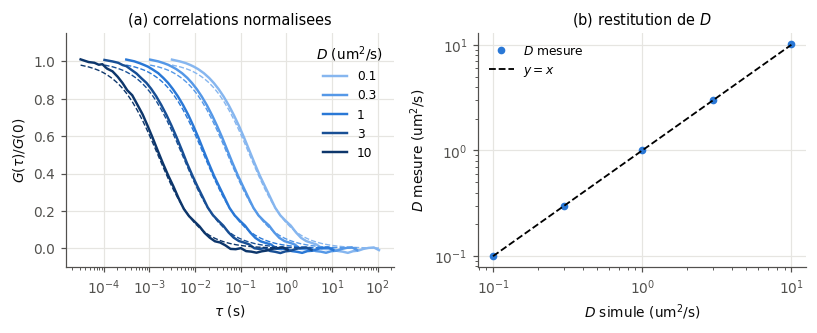

  D simule   tau_D attendu   tau_D mesure   D mesure   N mesure   dt (us)   T (s)
     0.10        156.25         156.86       0.10       0.97    1562.5   156.2
     0.30         52.08          52.07       0.30       0.97     520.8    52.1
     1.00         15.62          15.63       1.00       0.97     156.2    15.6
     3.00          5.21           5.26       2.97       0.97      52.1     5.2
    10.00          1.56           1.54      10.17       0.97      15.6     1.6


In [45]:
Ds3 = [0.1, 0.3, 1.0, 3.0, 10.0]
fig, ax = plt.subplots(1, 2, figsize=(7.5, 3.1))
res_D = []

for c, D in zip(seq(len(Ds3)), Ds3):
    tauD = W0**2/(4*D)
    tau, G, err = fcs(Boite(L3), D, 1000*tauD, tauD/100, n3, Faisceau(W0), n_rep=10, seed=11, cps=CPS)
    r = ajuste_fcs(tau, G, W0)
    res_D.append(r)
    
    ax[0].plot(tau, G/G[:3].mean(), color=c, lw=1.6, label="%g" % D)
    ax[0].plot(tau, modele_fcs(tau, 1., r["tau_D"]), color=c, lw=.9, ls="--")

ax[0].set_xscale("log")
ax[0].set_ylim(-0.1, 1.15)
ax[0].set_xlabel("$\\tau$ (s)")
ax[0].set_ylabel("$G(\\tau)/G(0)$")
ax[0].legend(title="$D$ (um$^2$/s)")
ax[0].set_title("(a) correlations normalisees")

ax[1].plot(Ds3, [r["D"] for r in res_D], "o", color=CAT[0], label="$D$ mesure")
ax[1].plot(Ds3, Ds3, "--", color="k", lw=1.2, label="$y = x$")
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_xlabel("$D$ simule (um$^2$/s)")
ax[1].set_ylabel("$D$ mesure (um$^2$/s)")
ax[1].legend()
ax[1].set_title("(b) restitution de $D$")

plt.show()

print("  D simule   tau_D attendu   tau_D mesure   D mesure   N mesure   dt (us)   T (s)")

for D, r in zip(Ds3, res_D):
    tauD = W0**2/(4*D)
    print("  %7.2f   %11.2f   %12.2f   %8.2f   %8.2f   %7.1f   %5.1f" % (D, 1e3*tauD, 1e3*r["tau_D"], r["D"], r["N"], 1e6*tauD/100, 1000*tauD))

**Conclusion.** $D$ déplace la courbe horizontalement sans changer son amplitude : $\tau_D$ passe
de 156 ms à 1,6 ms sur deux décades, et les valeurs ajustées collent aux valeurs attendues à mieux
que 2 % sur toute la gamme. La densité mesurée reste inchangée, ce qui confirme que mobilité et
concentration sont découplées.

Les cinq courbes ont la même allure et le même niveau de bruit parce que le pas d'échantillonnage et
la durée suivent $\tau_D$ : 1,6 ms et 156 s pour $D$ = 0,1 µm²/s, 16 µs et 1,6 s pour
$D$ = 10 µm²/s. C'est ce que fait un expérimentateur, qui choisit son binning et son temps
d'acquisition d'après la dynamique attendue. Avec un pas et une durée fixes, la même figure serait
soit sous-échantillonnée aux $D$ élevés, soit privée de statistique aux $D$ faibles.

## Impact de la densité (0,1 à 10 émetteurs par $\pi w_0^2$)

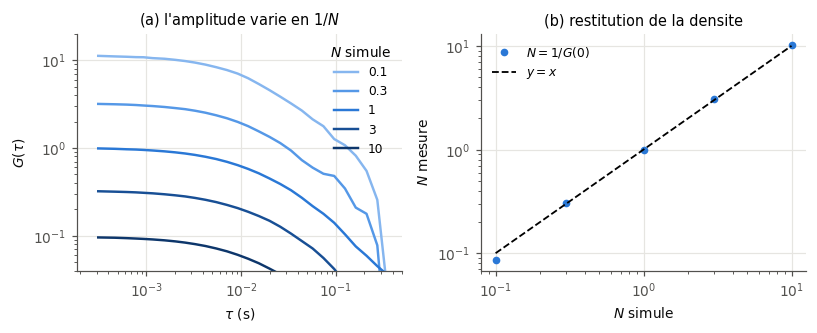

  N simule   molecules   densite (/um2)   G(0)     N mesure   D mesure (um2/s)
     0.10          10             0.5   11.586       0.09         1.17
     0.30          31             1.5    3.273       0.31         1.14
     1.00         103             5.1    1.007       0.99         0.99
     3.00         309            15.3    0.327       3.06         1.01
    10.00        1031            50.9    0.097      10.28         1.01


In [46]:
Neffs = [0.1, 0.3, 1.0, 3.0, 10.0]
fig, ax = plt.subplots(1, 2, figsize=(7.5, 3.1))
res_N = []

for c, Ne in zip(seq(len(Neffs)), Neffs):
    n = n_particules(Ne, L3**2, W0)
    tau, G, err = fcs(Boite(L3), D3, T3, DT3, n, Faisceau(W0), n_rep=6, seed=21, cps=CPS)
    r = ajuste_fcs(tau, G, W0)
    res_N.append(r)
    
    ax[0].plot(tau, G, color=c, lw=1.6, label="%g" % Ne)

ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_ylim(4e-2, 20)
ax[0].set_xlim(None, 0.5)
ax[0].set_xlabel("$\\tau$ (s)")
ax[0].set_ylabel("$G(\\tau)$")
ax[0].legend(title="$N$ simule")
ax[0].set_title("(a) l'amplitude varie en $1/N$")

ax[1].plot(Neffs, [r["N"] for r in res_N], "o", color=CAT[0], label="$N = 1/G(0)$")
ax[1].plot(Neffs, Neffs, "--", color="k", lw=1.2, label="$y = x$")
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_xlabel("$N$ simule")
ax[1].set_ylabel("$N$ mesure")
ax[1].legend()
ax[1].set_title("(b) restitution de la densite")

plt.show()

print("  N simule   molecules   densite (/um2)   G(0)     N mesure   D mesure (um2/s)")

for Ne, r in zip(Neffs, res_N):
    n = n_particules(Ne, L3**2, W0)
    print("  %7.2f   %9d   %13.1f   %6.3f   %8.2f   %10.2f" % (Ne, n, n/L3**2, 1/r["N"], r["N"], r["D"]))

**Conclusion.** L'amplitude est strictement inversement proportionnelle à la densité, sur deux
décades, sans effet sur $\tau_D$. La densité est restituée fidèlement de 0,1 à 10 émetteurs par
surface effective, soit de 0,5 à 51 molécules/µm².

Les deux extrémités restent néanmoins les plus délicates. À $N$ = 10, $G(0)$ ne vaut plus que 0,1 :
les fluctuations relatives sont faibles et la courbe atteint le plancher de bruit dès quelques
$\tau_D$, ce qui explique que l'axe soit borné sur la partie significative. À $N$ = 0,1,
l'amplitude est grande et facile à lire, mais les passages de molécules sont rares et il faut la
même durée d'acquisition pour accumuler assez d'événements. La FCS travaille au mieux autour de
$N \sim 1$.

## Deux populations de coefficients de diffusion différents

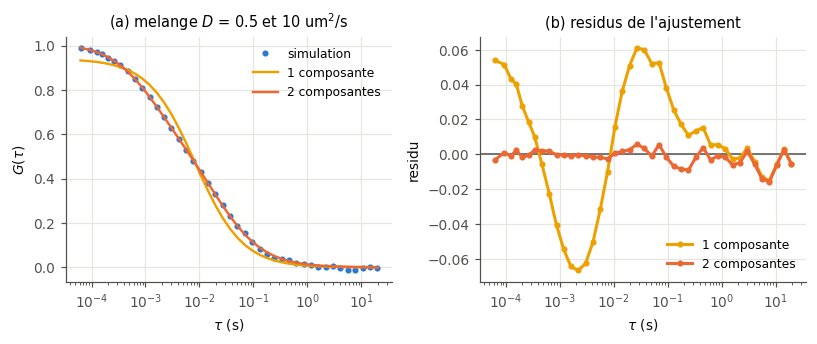

1 composante : N = 1.06   D = 1.87 um2/s  (aucune des deux valeurs simulees)
2 composantes: N = 0.99   D1 = 0.66 (0.5)   D2 = 11.4 (10.0)   fraction lente = 0.54 (0.50)


In [47]:
DA = 0.5   # coefficient de diffusion de la population lente, um^2/s
DB = 10.0  # coefficient de diffusion de la population rapide, um^2/s
NE = 0.5   # densite de chaque population, emetteurs par surface effective
nA = n_particules(NE, L3**2, W0)

DT_MIX = W0**2/(4*DB)/50
T_MIX = 1000*W0**2/(4*DA)
Gs = []

for k in range(4):
    _, FA = traces(Boite(L3), DA, T_MIX, DT_MIX, nA, Faisceau(W0), cps=CPS, shot=False, seed=300 + k)
    _, FB = traces(Boite(L3), DB, T_MIX, DT_MIX, nA, Faisceau(W0), cps=CPS, shot=False, seed=400 + k)
    tau, g = correlation(grenaille(FA + FB, k), dt=DT_MIX)
    Gs.append(g)

G2 = np.mean(Gs, 0)

r1 = ajuste_fcs(tau, G2, W0)
p, _ = curve_fit(modele_fcs2, tau, G2, maxfev=40000, p0=[G2[:3].mean(), W0**2/(4*DA), W0**2/(4*DB), .5])

fig, ax = plt.subplots(1, 2, figsize=(7.5, 3.2))

ax[0].plot(tau, G2, "o", color=CAT[0], ms=3, label="simulation")
ax[0].plot(tau, modele_fcs(tau, 1/r1["N"], r1["tau_D"]), color=CAT[3], lw=1.6, label="1 composante")
ax[0].plot(tau, modele_fcs2(tau, *p), color=CAT[1], lw=1.6, label="2 composantes")
ax[0].set_xscale("log")
ax[0].set_xlabel("$\\tau$ (s)")
ax[0].set_ylabel("$G(\\tau)$")
ax[0].legend()
ax[0].set_title("(a) melange $D$ = %g et %g um$^2$/s" % (DA, DB))

ax[1].axhline(0, color=GRIS, lw=1)
ax[1].plot(tau, G2 - modele_fcs(tau, 1/r1["N"], r1["tau_D"]), "o-", color=CAT[3], ms=3, label="1 composante")
ax[1].plot(tau, G2 - modele_fcs2(tau, *p), "o-", color=CAT[1], ms=3, label="2 composantes")
ax[1].set_xscale("log")
ax[1].set_xlabel("$\\tau$ (s)")
ax[1].set_ylabel("residu")
ax[1].legend()
ax[1].set_title("(b) residus de l'ajustement")

plt.show()

print("1 composante : N = %.2f   D = %.2f um2/s  (aucune des deux valeurs simulees)" % (r1["N"], r1["D"]))
print("2 composantes: N = %.2f   D1 = %.2f (%.1f)   D2 = %.1f (%.1f)   fraction lente = %.2f (0.50)"
      % (1/p[0], W0**2/(4*p[1]), DA, W0**2/(4*p[2]), DB, p[3]))

**Conclusion.** Le mélange produit une décroissance en deux marches. Le modèle à une composante
passe « au travers » et rend un $D$ intermédiaire qui ne correspond à aucune des deux populations,
avec des résidus structurés en S caractéristiques. Le modèle à deux composantes sépare correctement
les deux coefficients et leurs proportions. Un écart d'un facteur ~10 entre les deux $D$ est
nécessaire pour que la séparation soit fiable : en dessous, les deux marches se confondent.

## Bruit de grenaille

Le bruit de grenaille est bien un **bruit blanc ajouté au nombre de photons de chaque bin** :
décorrélé d'un bin à l'autre, il ne contribue à l'autocorrélation qu'en $\tau = 0$, donc il ne
déplace pas $G(\tau > 0)$ et ne dégrade que la **précision**.

Il a cependant une particularité : son amplitude n'est pas libre. Si un bin doit recevoir $\mu$
photons en moyenne, le détecteur en compte $\mathrm{Poisson}(\mu)$, dont la variance vaut $\mu$
elle-même. La quantité de bruit blanc est donc **fixée par le signal**, et c'est la brillance qui la
règle.

La brillance $B$ est un taux de comptage, en photons par seconde et par molécule. Multipliée par le
temps de bin $\Delta t$, elle donne le nombre de photons collectés par bin :

$$\mu = B\,\Delta t \times (\text{molécules éclairées}),
\qquad \frac{\mathrm{var}_{\rm grenaille}}{\mathrm{var}_{\rm signal}} = \frac{2}{B\,\Delta t}$$

Ce rapport ne dépend ni de la densité ni de $D$. Ci-dessous $B$ varie de 0,2 à 20 kHz, soit de 0,017
à 1,7 photon par bin, ce qui le fait passer de 64 à 0,6. Les trajectoires sont rigoureusement
identiques dans les trois cas, et les barres d'erreur sont mesurées **à trajectoire figée** pour
isoler le seul effet du comptage.

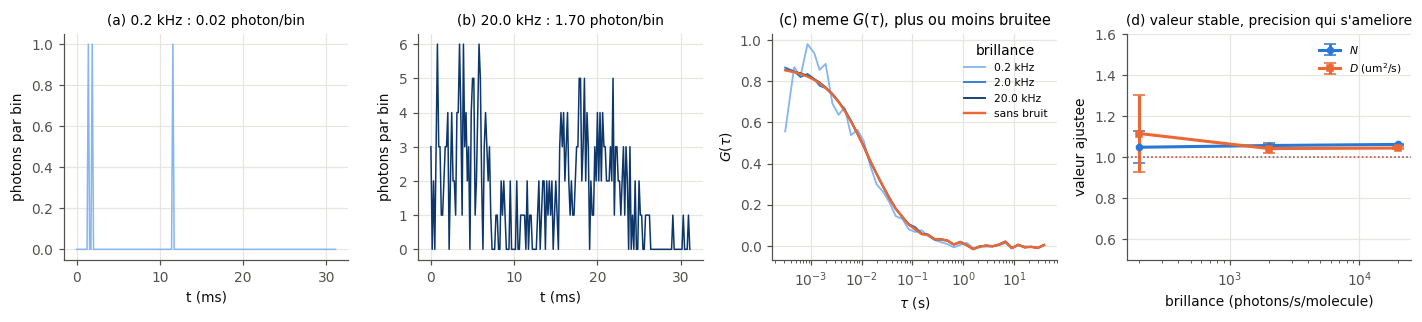

  brillance   ph/bin   var_gren/var_sig   N ajuste        D ajuste
     0.2 kHz    0.017               64.0   1.05 +- 0.077   1.11 +- 0.189
     2.0 kHz    0.170                6.4   1.06 +- 0.012   1.04 +- 0.023
    20.0 kHz    1.697                0.6   1.06 +- 0.003   1.04 +- 0.005

  (barres d'erreur : dispersion sur 6 tirages du bruit A TRAJECTOIRE FIGEE,
   ce qui isole l'effet du seul comptage des photons)


In [48]:
# 3 trajectoires de reference sans bruit, en unites de dt*I (cps=1).
# Les MEMES trois trajectoires servent aux trois brillances : la comparaison est
# controlee, seule la detection change.
maitresses_bg = [traces(Boite(L3), D3, 60., DT3, n3, Faisceau(W0),
                        cps=1., shot=False, seed=g)[1] for g in (31, 51, 71)]

taux = [2e2, 2e3, 2e4]
fig, ax = plt.subplots(1, 4, figsize=(13, 3.0))
moy_N, moy_D, sig_N, sig_D = [], [], [], []
fen = slice(0, 200)                          # ~2 temps de residence pour l'affichage
t_fen = np.arange(200)*DT3*1e3

for c, cps in zip(seq(3), taux):
    tous_N, tous_D = [], []
    disp_N, disp_D = [], []                  # dispersion A TRAJECTOIRE FIGEE

    for k, F0k in enumerate(maitresses_bg):
        Nk, Dk = [], []

        for graine in range(6):              # 6 tirages du bruit sur la meme trajectoire
            F = grenaille(F0k*cps, 5 + 100*k + graine)
            tau, G = correlation(F, dt=DT3)
            r = ajuste_fcs(tau, G, W0)
            Nk.append(r["N"])
            Dk.append(r["D"])

            if k == 0 and graine == 0:
                if cps == taux[0]:
                    ax[0].plot(t_fen, F[fen], color=c, lw=1)
                if cps == taux[-1]:
                    ax[1].plot(t_fen, F[fen], color=c, lw=1)
                ax[2].plot(tau, G, color=c, lw=1.2, label="%.1f kHz" % (cps/1e3))

        tous_N += Nk
        tous_D += Dk
        disp_N.append(np.std(Nk))            # dispersion due au seul bruit de grenaille
        disp_D.append(np.std(Dk))

    moy_N.append(np.mean(tous_N))
    moy_D.append(np.mean(tous_D))
    sig_N.append(np.mean(disp_N))
    sig_D.append(np.mean(disp_D))

for a_, cps, lettre in [(ax[0], taux[0], "a"), (ax[1], taux[-1], "b")]:
    a_.set_xlabel("t (ms)")
    a_.set_ylabel("photons par bin")
    a_.set_title("(%s) %.1f kHz : %.2f photon/bin"
                 % (lettre, cps/1e3, (maitresses_bg[0]*cps).mean()), fontsize=9)

ax[2].plot(tau, correlation(maitresses_bg[0], dt=DT3)[1], color=CAT[1], lw=1.6,
           label="sans bruit")
ax[2].set_xscale("log")
ax[2].set_xlabel("$\\tau$ (s)")
ax[2].set_ylabel("$G(\\tau)$")
ax[2].legend(title="brillance", fontsize=7)
ax[2].set_title("(c) meme $G(\\tau)$, plus ou moins bruitee")

# barres d'erreur = dispersion du SEUL bruit de grenaille, trajectoire figee
ax[3].errorbar(taux, moy_N, sig_N, fmt="o-", color=CAT[0], capsize=4, label="$N$")
ax[3].errorbar(taux, moy_D, sig_D, fmt="s-", color=CAT[1], capsize=4, label="$D$ (um$^2$/s)")
ax[3].axhline(N_EFF, color=CAT[0], ls=":", lw=1)
ax[3].axhline(D3, color=CAT[1], ls=":", lw=1)
ax[3].set_xscale("log")
ax[3].set_ylim(0.5, 1.6)
ax[3].set_xlabel("brillance (photons/s/molecule)")
ax[3].set_ylabel("valeur ajustee")
ax[3].legend(fontsize=7)
ax[3].set_title("(d) valeur stable, precision qui s'ameliore", fontsize=9)

plt.show()

print("  brillance   ph/bin   var_gren/var_sig   N ajuste        D ajuste")

for cps, mN, sN, mD, sD in zip(taux, moy_N, sig_N, moy_D, sig_D):
    print("  %6.1f kHz  %7.3f   %16.1f   %.2f +- %.3f   %.2f +- %.3f"
          % (cps/1e3, (maitresses_bg[0]*cps).mean(), 2/(cps*DT3), mN, sN, mD, sD))

print()
print("  (barres d'erreur : dispersion sur 6 tirages du bruit A TRAJECTOIRE FIGEE,")
print("   ce qui isole l'effet du seul comptage des photons)")

**Conclusion.** Le bruit de grenaille se comporte exactement comme un bruit blanc additif : il ne
biaise pas les paramètres. Les valeurs ajustées restent à $N$ = 1,05 et $D$ = 1,04 sur deux décades
de brillance (panneau d), alors que la variance de comptage passe de 64 fois celle du signal à
0,6 fois.

Ce qu'il détruit, c'est la **précision**, et de façon spectaculaire :

| Brillance | Photons/bin | Écart-type sur $N$ | sur $D$ |
|---|---|---|---|
| 0,2 kHz | 0,017 | 0,077 | 0,189 |
| 2 kHz | 0,17 | 0,012 | 0,023 |
| 20 kHz | 1,7 | 0,003 | 0,005 |

Un facteur 100 sur la brillance vaut un facteur 25 sur l'incertitude de $N$ et 38 sur celle de $D$.
Les panneaux (a) et (b) en donnent la raison physique : à 0,2 kHz la trace ne contient presque que
des zéros, avec un photon isolé de temps en temps, alors qu'à 20 kHz la même trajectoire donne zéro
à six photons par bin et le passage des molécules se lit directement.

C'est pourquoi la brillance est le principal critère de qualité d'un montage de FCS. Elle ne déplace
pas la valeur mesurée, elle décide du temps d'acquisition nécessaire pour l'atteindre.

## Durée de l'acquisition

La même trace est tronquée à des durées croissantes, de 0,5 à 60 s, soit de 32 à 3840 temps de
résidence. Six traces indépendantes servent à estimer la dispersion à chaque durée.

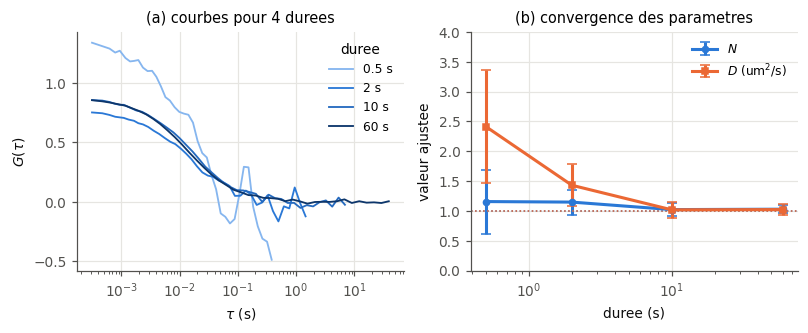

  duree (s)   tau_D    N ajuste        D ajuste        dispersion sur N
       0.5      32   1.16 +- 0.54   2.41 +- 0.95         46 %
       2.0     128   1.15 +- 0.21   1.43 +- 0.35         18 %
      10.0     640   1.02 +- 0.11   1.02 +- 0.13         11 %
      60.0    3840   1.03 +- 0.07   1.02 +- 0.09          6 %


In [49]:
durees3 = [0.5, 2., 10., 60.]
graines = [31, 51, 71, 91, 111, 131]

maitresses = [traces(Boite(L3), D3, 60., DT3, n3, Faisceau(W0), cps=1., shot=False, seed=g)[1] for g in graines]

fig, ax = plt.subplots(1, 2, figsize=(7.5, 3.1))
moy_N, moy_D, err_N, err_D = [], [], [], []

for c, T in zip(seq(len(durees3)), durees3):
    Ns, Ds = [], []

    for k, F0k in enumerate(maitresses):
        F = grenaille(F0k[:int(T/DT3)]*CPS, 6 + k)
        tau, G = correlation(F, dt=DT3)
        r = ajuste_fcs(tau, G, W0)
        Ns.append(r["N"])
        Ds.append(r["D"])

        if k == 0:
            ax[0].plot(tau, G, color=c, lw=1.2, label="%g s" % T)

    moy_N.append(np.mean(Ns))
    moy_D.append(np.mean(Ds))
    err_N.append(np.std(Ns))
    err_D.append(np.std(Ds))

ax[0].set_xscale("log")
ax[0].set_xlabel("$\\tau$ (s)")
ax[0].set_ylabel("$G(\\tau)$")
ax[0].legend(title="duree")
ax[0].set_title("(a) courbes pour 4 durees")

ax[1].errorbar(durees3, moy_N, err_N, fmt="o-", color=CAT[0], capsize=3, label="$N$")
ax[1].errorbar(durees3, moy_D, err_D, fmt="s-", color=CAT[1], capsize=3, label="$D$ (um$^2$/s)")
ax[1].axhline(N_EFF, color=CAT[0], ls=":", lw=1)
ax[1].axhline(D3, color=CAT[1], ls=":", lw=1)
ax[1].set_xscale("log")
ax[1].set_ylim(0, 4)
ax[1].set_xlabel("duree (s)")
ax[1].set_ylabel("valeur ajustee")
ax[1].legend()
ax[1].set_title("(b) convergence des parametres")

plt.show()

print("  duree (s)   tau_D    N ajuste        D ajuste        dispersion sur N")

for T, mN, eN, mD, eD in zip(durees3, moy_N, err_N, moy_D, err_D):
    print("  %8.1f  %6.0f   %.2f +- %.2f   %.2f +- %.2f   %8.0f %%" % (T, T/TAU_D3, mN, eN, mD, eD, 100*eN/mN))


**Conclusion.** La durée ne biaise **ni $N$ ni $D$**, elle contrôle leur **précision**. La
dispersion sur $N$ passe de 46 % à 0,5 s à 6 % à 60 s, une décroissance compatible avec le
$T^{-1/2}$ déjà rencontré pour l'estimation de $D$ par MSD au simulateur 1.

$D$ converge plus lentement que $N$, et c'est logique : l'amplitude $G(0)$ se lit sur le plateau aux
courts $\tau$, où les points sont nombreux, alors que $\tau_D$ se lit sur la décroissance, dont
chaque point coûte un temps de résidence entier. À 0,5 s, soit 32 temps de résidence, on mesure
$D = 2{,}4 \pm 1{,}0$ au lieu de 1 : la courbe garde pourtant une allure plausible, et c'est
seulement en répétant la mesure que l'on voit qu'elle ne veut rien dire.

En pratique il faut au moins $10^3$ temps de résidence, ici une quinzaine de secondes, pour que les
deux paramètres soient stables. Cela recoupe la durée d'acquisition typique de 10 à 120 s indiquée
par Yu *et al.* pour la FCS conventionnelle.

# Synthèse

| Observable | Ce que porte l'**amplitude** | Ce que porte l'**échelle de temps** |
|---|---|---|
| MSD | $4\sigma^2$ : précision de localisation ; plateau : taille du confinement | pente $4D$ |
| FRAP | plateau : fraction mobile | $t_{1/2} = 0{,}224 R_b^2/D$ |
| FCS $G(\tau)$ | $G(0) = 1/N$ : densité | $\tau_D = w_0^2/4D$ |

Trois constats transversaux :

1. **Amplitude et temps sont découplés** dans les trois mesures. La concentration et la mobilité
   se lisent sur deux caractéristiques indépendantes de la même courbe.
2. **La durée d'acquisition ne biaise jamais le résultat, elle en fixe la précision.** Toutes les
   estimations convergent vers la bonne valeur ; ce sont les barres d'erreur qui diminuent, en
   $T^{-1/2}$.
3. **La géométrie modifie la forme des courbes, pas seulement leur échelle.** Un tube donne une
   MSD qui plafonne sur un seul axe et un retour FRAP en $t^{-1/2}$, alors que la même mesure en
   2D libre donne une droite et un retour en $t^{-1}$. Utiliser un modèle de mauvaise géométrie
   conduit à attribuer à tort à la mobilité ce qui relève de la structure.

# Références

Toute la théorie utilisée ci-dessus provient des trois articles du cours correspondant aux trois
simulateurs.

1. **X. Michalet**, *Mean square displacement analysis of single-particle trajectories with
   localization error: Brownian motion in an isotropic medium*, Phys. Rev. E **82**, 041914 (2010).
   Simulateur 1 : estimateur de MSD (éq. 7), MSD en présence d'erreur de localisation et de temps de
   pose (éq. 14-15), extraction de $D$ et $\sigma$ (éq. 17-18), incertitude de localisation statique
   et dynamique (éq. 2 et 4), nombre optimal de points d'ajustement (éq. 30).

2. **A. K. Kenworthy**, *What's past is prologue: FRAP keeps delivering 50 years later*,
   Biophys. J. **122**, 3577 (2023). Simulateur 2 : les deux informations portées par une courbe de
   FRAP ($t_{1/2}$ et fraction mobile), nécessité d'un modèle adapté à la géométrie et à la taille
   de la zone blanchie, aux conditions aux limites et à la dimensionnalité du retour, hypothèses de
   base de la technique.

3. **L. Yu, Y. Lei, Y. Ma, M. Liu, J. Zheng, D. Dan, P. Gao**, *A comprehensive review of
   fluorescence correlation spectroscopy*, Front. Phys. **9**, 644450 (2021). Simulateur 3 :
   définition de $G(\tau)$ (éq. 1), modèle de diffusion et sa réduction au cas 2D (éq. 2),
   $\tau_D = r_0^2/4D$, algorithme multi-tau, ordres de grandeur du tableau 1.

Le quatrième article du dossier, **M. A. Digman et E. Gratton**, *Imaging barriers to diffusion by
pair correlation functions*, Biophys. J. **97**, 665 (2009), portait sur le simulateur 4
(corrélation pairée et barrières), retiré du devoir.